# 009. スケーリング則(Scaling Laws)

## 1. 概要 / Overview

計算量予算(compute budget)$C$ が与えられたとき、それをモデルサイズ $N$ と訓練トークン数 $D$ にどう配分すれば損失を最小化できるかという問題を扱う。Kaplan et al. (2020) と Hoffmann et al. (2022, Chinchilla)はこの **計算量最適(compute-optimal)** な配分則を導いたが、両者は大きく異なる指数($a \approx 0.73$ と $a \approx 0.5$、$N_{opt}(C) \propto C^{a}$)を報告した。Porian et al. (2024) はこの食い違いを、計算量の数え方・warmup の長さ・スケール依存の最適化ハイパーパラメータ調整という 3 つの交絡要因により説明した。

**本トピックの規模上の制約**: Google Colab 無料枠の T4 GPU で振れる計算量の範囲はせいぜい 1.5 桁(コンピュートバジェットを 5 水準・公比 2 で振っても $2^4 = 16$ 倍、$\log_{10} 16 \approx 1.2$)であり、べき指数 $a$ の絶対値を原論文の値(0.73 や 0.5)と一致させることは原理的に不可能である。したがって本トピックが検証するのは **指数の値そのものではなく、小スケールでも成立する構造的な主張** に限る。具体的には、計算量最適なモデルサイズ $N_{opt}(C)$ のべき指数 $a$ を、3 つの異なる角度から攻める。

- **実験 A**: そもそも $N_{opt}(C)$ がべき乗則(対数空間で直線)として記述できるか(IsoFLOP プロファイル、Hoffmann et al., 2022 の Approach 2)。
- **実験 B**: 計算量の数え方(出力層を含めるかどうか)が指数 $a$ の推定値に与える影響。Porian et al. (2024) が特定した 3 要因のうち要因 1(最終層の計算量)のみを、既存の学習結果の再解析だけで検証する。
- **実験 C**: IsoFLOP プロファイル(Approach 2)による指数推定と、パラメトリックあてはめ(Approach 3)から導出した指数推定が内的に整合するか。

$a$ の推定値が Chinchilla の 0.5 や Kaplan らの 0.73 に近いかどうかは判定基準にせず、参考値として事後的に報告するに留める。


## 2. 参考論文 / References

1. Kaplan, J., McCandlish, S., Henighan, T., Brown, T. B., Chess, B., Child, R., Gray, S., Radford, A., Wu, J., Amodei, D. "Scaling Laws for Neural Language Models." arXiv:2001.08361, 2020. https://arxiv.org/abs/2001.08361
2. Hoffmann, J., Borgeaud, S., Mensch, A., et al. "Training Compute-Optimal Large Language Models." NeurIPS 2022. arXiv:2203.15556. https://arxiv.org/abs/2203.15556
3. Porian, T., Wortsman, M., Jitsev, J., Schmidt, L., Carmon, Y. "Resolving Discrepancies in Compute-Optimal Scaling of Language Models." NeurIPS 2024. arXiv:2406.19146. https://arxiv.org/abs/2406.19146

本トピックのモデル学習は、006・007・008 の以下の論文にも依拠する(理論の再掲はしない)。

- Radford, A. et al., "Language Models are Unsupervised Multitask Learners", 2019(GPT-2、バイトレベル BPE)
- Su, J. et al., "RoFormer: Enhanced Transformer with Rotary Position Embedding", Neurocomputing 2024(RoPE)
- Loshchilov, I., Hutter, F., "Decoupled Weight Decay Regularization", ICLR 2019(AdamW)
- Besiroglu, T., Erdil, E., Barnett, M., You, J. "Chinchilla Scaling: A replication attempt." arXiv:2404.10102, 2024(Chinchilla のパラメトリックあてはめが初期値に敏感であることの指摘。本文中で言及する)


## 3. 理論 / Theory

### 3.1 動機・課題

計算量予算 $C$(浮動小数点演算回数)が与えられたとき、それをモデルサイズ $N$(非埋め込みパラメータ数、non-embedding parameter count)と訓練トークン数 $D$ にどう配分すべきか。この問いに Kaplan et al. (2020) と Hoffmann et al. (2022) は大きく異なる答えを出した。Kaplan らは $N_{opt}(C) \propto C^{a}$ の指数を $a \approx 0.73$(モデルサイズを積極的に増やすべき)と報告し、Hoffmann らは $a \approx 0.50$(モデルサイズとデータ量を同程度に増やすべき)と報告した。この 2 つの結果は、GPT-3(Kaplan らの指針に基づく)が同時代の他モデルに比べて過大なモデルサイズ・過小な訓練データ量になっていた、という業界的に大きな影響を持つ違いだった。Porian et al. (2024) はこの食い違いの原因を、計算量の数え方・warmup の長さ・スケール依存の最適化ハイパーパラメータ調整という 3 つの交絡要因に帰着させ、これらを補正すると Kaplan らの手法でも Chinchilla に近い指数が得られることを示した。

### 3.2 記号の定義と計算量の見積もり

以下の記号を用いる。

- $N$: 非埋め込みパラメータ数(non-embedding parameter count)。埋め込み層・出力層を除く Transformer 本体のパラメータ数(`count_non_embedding_parameters`、006 で導入)。
- $D$: 訓練トークン数。
- $C$: 計算量予算(浮動小数点演算回数、FLOPs)。
- $L$: 検証損失。009 では bits-per-byte(006 で確立した、トークナイザに依存しない指標)を用いる。009 は全条件で同一トークナイザ(3.1 節参照)を使うため perplexity でも比較可能だが、シリーズ内の一貫性のため bits-per-byte を使う。
- $V$: 語彙サイズ、$d_{model}$: モデルの隠れ次元、$n_{layer}$: 層数、$n_{ctx}$: 系列長(sequence length)。
- $E, A, B, \alpha, \beta$: Chinchilla のパラメトリックあてはめ(3.3 節 Approach 3)の係数・指数。
- $a, b$: 計算量最適配分の指数($N_{opt}(C) \propto C^{a}$、$D_{opt}(C) \propto C^{b}$)。

**トークンあたりの計算量**: 順伝播 1 パラメータあたり 2 回の演算(乗算+加算)、逆伝播を含めて 3 倍という標準的な近似(Kaplan et al., 2020)から出発する。1 トークンあたりの計算量を、以下の 3 つの項の和として見積もる(`estimate_flops_per_token`、`src/scaling/laws.py`)。

$$
C_{\text{token}} = \underbrace{6N}_{\text{本体}} + \underbrace{6 V d_{model}}_{\text{出力層}} + \underbrace{12 \, n_{layer} \, n_{ctx} \, d_{model}}_{\text{Attention の系列長依存項}}
$$

- **本体**(embedding 層と出力層を除く Transformer 本体): $6N$。
- **出力層**(重み共有(weight tying)により埋め込み行列と同一の行列、006 参照): $6 V d_{model}$。出力層は $V \times d_{model}$ の行列演算であり、1 トークンあたり $2 V d_{model}$ の順伝播演算(逆伝播を含め 3 倍で $6 V d_{model}$)。
- **Attention の系列長依存項**: 各層の Attention スコア計算($QK^\top$ と重み付き和)が系列長 $n_{ctx}$ に比例した追加コストを持つ(Kaplan et al., 2020 の $C_{\text{attn}}$)。

**本トピックの中心的な観察**: $N$ は概ね $d_{model}^2$ に比例する(Attention・Feed-Forward Network の重み行列がいずれも $d_{model}$ の 2 次関数であるため)一方、出力層の項 $6 V d_{model}$ は $d_{model}$ に対して 1 次でしか増加しない。したがって **モデルが小さいほど、出力層が全計算量に占める割合が相対的に大きくなる**。009 の規模($V = 8192$、$d_{model} \le 400$ 程度)ではこの割合が数十パーセントに達することを、次のコードセルで具体的な数値表として示す。


In [1]:
# 環境セットアップ(Google Colab)
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/kojikojiprg/ai-theories.git
    %cd ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt
# ローカル(Jupyter)実行時は、リポジトリルートで起動していればそのまま動く。
import functools
import json
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from src.data.text import (
    encode_corpus,
    load_english_wikipedia_corpus_with_fallback,
    make_evaluation_windows,
    split_train_val_text,
)
from src.data.tokenizer import BPEIDTokenizer, load_bpe_id_tokenizer_from_hub
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.gpt import GPTLanguageModel
from src.scaling.laws import (
    BootstrapResult,
    ChinchillaParametricFit,
    FrontierResult,
    GridPoint,
    IsoFLOPParabolaFit,
    PowerLawFit,
    SaturatingPowerLawFit,
    bootstrap_scaling_analysis,
    compute_optimal_allocation_exponents,
    estimate_flops_per_token,
    fit_chinchilla_parametric,
    fit_isoflop_parabola,
    fit_power_law,
    fit_saturating_power_law,
    reconstruct_optimal_frontier,
)
from src.training.optimizer import AdamW
from src.training.schedule import compute_warmup_cosine_learning_rate
from src.training.trainer import train_language_model
from src.utils.statistics import compute_bits_per_byte, count_non_embedding_parameters
from src.utils.visualization import plot_isoflop_profile, plot_learning_curves, plot_optimal_frontier

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)
print(f"torch: {torch.__version__} / device: {device}")

ROOT = Path(".")


Cloning into 'ai-theories'...
remote: Enumerating objects: 595, done.
remote: Counting objects: 100% (93/93), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 595 (delta 48), reused 56 (delta 28), pack-reused 502 (from 1)
Receiving objects: 100% (595/595), 7.12 MiB | 14.44 MiB/s, done.
Resolving deltas: 100% (304/304), done.
/content/ai-theories
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 91.1 MB/s eta 0:00:00
Using Python 3.13.15 environment at: /usr
Resolved 52 packages in 319ms
Prepared 28 packages in 45.67s
Uninstalled 14 packages in 740ms
Installed 28 packages in 324ms
 - click==8.5.0
 + click==8.4.2
 - cuda-bindings==12.9.7
 + cuda-bindings==13.3.1
 - cuda-pathfinder==1.7.0
 + cuda-pathfinder==1.6.0
 - cuda-toolkit==12.8.1
 + cuda-toolkit==13.0.3.0
 - filelock==3.32.4
 + filelock==3.32.2
 - fsspec==2025.3.0
 + fsspec==2026.7.0
 - matplotlib==3.10.0
 + matplotlib==3.11.1
 - numpy==2.1.3
 + numpy==2.5.2
 + nvidia-cublas==13.1.1.3
 + nvidia-cuda-cupt

### 3.2.1 出力層が計算量に占める割合(数値表)

009 の学習グリッド(6.1 節)で使う`d_model`の水準(32・64・96・128・192、語彙サイズ $V=8192$、$n_{layer}=4$、$n_{ctx}=256$)について、本体の計算量 $6N$ に対して出力層の計算量 $6 V d_{model}$ がどの程度の割合を占めるかを示す。ここでの $N$ は 006・008 と同じ構成(RoPE・RMSNorm・SwiGLU、6.1 節で確定)のモデルを実際に構築して`count_non_embedding_parameters`で実測した値である。


In [2]:
VOCAB_SIZE = 8192
N_LAYER = 4
HEAD_DIM = 32  # 1 ヘッドあたりの次元を固定し、num_heads = d_model // HEAD_DIM とする
SEQUENCE_LENGTH = 256  # 006・008 と揃える
D_MODEL_LEVELS = [32, 64, 96, 128, 192]  # 009 第 2 ラウンド修正: 下方に拡張・上限側を間引いた(2.1 節参照)
MID_D_MODEL_IDX = len(D_MODEL_LEVELS) // 2  # 中央の水準を指すインデックス(以降、D_MODEL_LEVELS[2] の直書きは使わない)


def build_gpt_model(d_model: int, num_layers: int = N_LAYER, max_seq_len: int = SEQUENCE_LENGTH):
    '''RoPE・RMSNorm・SwiGLU の構成(006・008 と同一)で GPTLanguageModel を構築する。'''
    num_heads = d_model // HEAD_DIM
    swiglu_d_ff = round((2 / 3) * (d_model * 4))  # 004: 標準 FFN とパラメータ数を揃えるための丸め
    rope = RotaryPositionEmbedding(d_model // num_heads, max_position=max_seq_len)
    return GPTLanguageModel(
        vocabulary_size=VOCAB_SIZE,
        d_model=d_model,
        num_layers=num_layers,
        num_heads=num_heads,
        d_ff=swiglu_d_ff,
        max_sequence_length=max_seq_len,
        positional_transform=rope,
        normalization_factory=RMSNorm,
        feed_forward_factory=lambda: SwiGLUFeedForwardNetwork(d_model, swiglu_d_ff),
        tie_embeddings=True,
        norm_first=True,
    )


_measured_N = {}
print(f"{'d_model':>8} {'num_heads':>10} {'N (実測)':>12} {'body 6N':>14} {'output 6Vd':>14} {'output比率':>10}")
for d_model in D_MODEL_LEVELS:
    m = build_gpt_model(d_model)
    n = count_non_embedding_parameters(m)
    _measured_N[d_model] = n
    body_flops = 6 * n
    output_flops = 6 * VOCAB_SIZE * d_model
    ratio = output_flops / (body_flops + output_flops)
    num_heads = d_model // HEAD_DIM
    print(f"{d_model:>8} {num_heads:>10} {n:>12,} {body_flops:>14,.0f} {output_flops:>14,.0f} {ratio:>9.1%}")

_n_ratios = [
    _measured_N[D_MODEL_LEVELS[i + 1]] / _measured_N[D_MODEL_LEVELS[i]] for i in range(len(D_MODEL_LEVELS) - 1)
]
print(f"\n隣接 d_model 間の N の比: {[round(r, 3) for r in _n_ratios]}(目標 2.0)")


 d_model  num_heads       N (実測)        body 6N     output 6Vd   output比率
      32          1       49,312        295,872      1,572,864     84.2%
      64          2      197,440      1,184,640      3,145,728     72.6%
      96          3      443,232      2,659,392      4,718,592     64.0%
     128          4      787,072      4,722,432      6,291,456     57.1%
     192          6    1,771,200     10,627,200      9,437,184     47.0%

隣接 d_model 間の N の比: [4.004, 2.245, 1.776, 2.25](目標 2.0)


出力層の割合は最小の`d_model=32`で最も大きく、`d_model`が増えるにつれ低下する(本体の計算量が $d_{model}^2$ で増える一方、出力層は $d_{model}$ の 1 次でしか増えないため)。この非対称性が、計算量の数え方(出力層を含めるか)がスケーリング指数の推定値に影響を与えるという実験 B の理論的根拠である。


### 3.3 Chinchilla の 3 つのアプローチ

Hoffmann et al. (2022) は、計算量最適な配分則を 3 つの独立なアプローチで推定し、結果が一致することを示した。

- **Approach 1**: モデルサイズ $N$ を固定して訓練ステップ数(= $D$)を振り、各 $N$ について損失 $L$ が最小になる訓練曲線の下側包絡線(minimum envelope)を取る。
- **Approach 2(IsoFLOP プロファイル、本トピックの主軸)**: 計算量予算 $C$ を固定して $N$(したがって $D = C/(6N)$)を振る。$(\log N, L)$ の点は下に凸な放物線状になり、その頂点が $N_{opt}(C)$ を与える。
- **Approach 3(パラメトリックあてはめ)**: $L(N, D) = E + A/N^{\alpha} + B/D^{\beta}$ という関数形を学習グリッド全体にあてはめ、閉形式で $N_{opt}(C)$・$D_{opt}(C)$ を導く。

以下、Approach 3 の閉形式解を導出する。制約 $C = 6ND$(本体のみの数え方、5.2 節)の下で $D = C/(6N)$ を $L$ に代入すると

$$
L(N) = E + A N^{-\alpha} + B (6N/C)^{\beta} = E + A N^{-\alpha} + B \, 6^{\beta} C^{\beta} N^{-\beta}
$$

$N$ について微分し 0 と置く。

$$
\frac{\partial L}{\partial N} = -\alpha A N^{-\alpha - 1} + \beta B \, 6^{\beta} C^{\beta} \, (-1) N^{-\beta - 1} \cdot (-1)
$$

やや煩雑になるので、$D = C/(6N)$ を保ったまま $N, D$ の両方を変数として、ラグランジュの未定乗数法で $C = 6ND$ の制約下の最小化を行う方が見通しがよい。$\mathcal{L} = E + A N^{-\alpha} + B D^{-\beta} - \lambda (6ND - C)$ とおき、$N, D, \lambda$ について偏微分を 0 と置く。

$$
\frac{\partial \mathcal{L}}{\partial N} = -\alpha A N^{-\alpha - 1} - 6 \lambda D = 0, \qquad
\frac{\partial \mathcal{L}}{\partial D} = -\beta B D^{-\beta - 1} - 6 \lambda N = 0
$$

2 式から $\lambda$ を消去する。第 1 式より $\lambda = -\alpha A N^{-\alpha - 1} / (6D)$、第 2 式より $\lambda = -\beta B D^{-\beta - 1} / (6N)$。両者を等置すると

$$
\frac{\alpha A N^{-\alpha - 1}}{D} = \frac{\beta B D^{-\beta - 1}}{N}
\quad \Longrightarrow \quad
\alpha A N^{-\alpha} = \beta B D^{-\beta}
$$

（両辺に $ND$ を掛けて整理した。）この関係と制約 $D = C/(6N)$ を組み合わせると、$N^{-\alpha} \propto N^{\beta}$($D^{-\beta} \propto N^{\beta}$ に $D \propto 1/N$ を代入)より $N^{\alpha + \beta} \propto C^{\beta}$、すなわち

$$
\boxed{N_{opt}(C) \propto C^{a}, \quad a = \frac{\beta}{\alpha + \beta}}
\qquad\qquad
\boxed{D_{opt}(C) \propto C^{b}, \quad b = \frac{\alpha}{\alpha + \beta}}
$$

（$a + b = 1$ は $C = 6ND$、$N_{opt} D_{opt} \propto C$ から自明に整合する。）この導出は **$C$ が $ND$ に比例することを前提としている** 点に注意する。出力層を含む数え方(実験 B)では $C$ は $ND$ に単純比例しないため、この閉形式は使えない。実験 C(6.7 節)で`compute_optimal_allocation_exponents`を使う際は、必ず本体のみの数え方で得られた $(\alpha, \beta)$ を用いる。

```mermaid
flowchart LR
    subgraph Approach1["Approach 1: 訓練曲線の下側包絡線"]
        A1["N を固定"] --> A2["D(ステップ数)を振る"] --> A3["各 N の最小損失の軌跡"]
    end
    subgraph Approach2["Approach 2: IsoFLOP プロファイル(本トピックの主軸)"]
        B1["C を固定"] --> B2["N を振る(D = C/6N)"] --> B3["(log N, L) に放物線をあてはめ、頂点が N_opt(C)"]
    end
    subgraph Approach3["Approach 3: パラメトリックあてはめ"]
        C1["学習グリッド全体"] --> C2["L(N,D) = E + A/N^a + B/D^b をあてはめ"] --> C3["閉形式で N_opt(C), D_opt(C) を導出"]
    end
```


### 3.4 Kaplan と Chinchilla の食い違いと 3 要因

Porian et al. (2024) は、Kaplan らの指数($a \approx 0.73$)と Hoffmann らの指数($a \approx 0.5$)の食い違いを、以下の 3 要因に帰着させた。

1. **最終層の計算量**: Kaplan らは計算量の見積もりから出力層(3.2 節の $6 V d_{model}$ 項)を除外しており、小さいモデルの計算量を過小評価していた。出力層を除外すると、小さいモデルは「実際より少ない計算量で今の損失を達成した」ことになり、同じ計算量予算に対して相対的に有利に評価される。この結果、低い計算量予算での $N_{opt}$ が実際より小さく見積もられ、フロンティアの傾き($a$)が急になる(過大評価される)。
2. **warmup の長さ**: 固定ステップ数の warmup は、訓練ステップ数が少ないラン(小さい計算量予算)ほど、訓練全体に占める warmup の割合が大きくなり不利に働く。
3. **スケール依存の最適化ハイパーパラメータ調整**: モデルサイズごとに学習率などを調整しないと、最適配分の推定が歪む。

これらを補正すると、Kaplan らの手法(Approach 1 に近い手法)でも Chinchilla のスケーリング則とよく一致することを Porian らは示した。また、Hoffmann らが示唆した仮説(学習率の減衰(decay)を訓練終了時点に正確に合わせることがスケーリング則の妥当性に重要)に反して、**学習率の減衰の丁寧な扱いはスケーリング則の妥当性に必須ではない** と Porian らは結論している。

**009 で検証するのは要因 1(最終層の計算量)のみである。** 理由は、要因 1 は既存の学習結果の計算量の数え方を変えるだけの再解析で検証でき、要因 2(warmup)・要因 3(最適化ハイパーパラメータ)は追加の学習グリッド(warmup 長・学習率を独立変数として振った別グリッド)を要するという、**観測結果とは独立な** 実装コスト上の理由による(結果を見てから要因 1 だけを選んだのではない)。要因 2・要因 3 は 6.2 節の固定条件として扱う(要因 2 は比例 warmup で回避する側に、要因 3 は全条件で学習率を固定する交絡として明示的に残す)。

### 3.5 解析パイプラインのデータフロー

学習グリッド(モデルサイズ x 計算量予算)から実験 A〜C の指数推定に至るデータフローを示す(6.4 節で詳述)。Mermaid は Google Colab 上では描画されないため、本文の数式・文章だけでも理解が成立するように 6.4 節に文章での説明を併記する。

```mermaid
flowchart TD
    Grid["学習グリッド: 5 d_model x 5 計算量予算(+ノイズ床 5 シード)"]
    Grid --> Measure["各セルの実測 (N, D, L) を記録"]
    Measure --> Sat["d_model ごとに (D, L) へ飽和べき乗則をあてはめ"]
    Sat --> IsoFLOP["目標 C ごとに (log N, L) へ放物線をあてはめ(内点のみ)"]
    IsoFLOP --> FrontierA["log N_opt vs log C のべき乗則(数え方=本体のみ)"]
    IsoFLOP --> FrontierB["log N_opt vs log C のべき乗則(数え方=本体+出力層)"]
    Measure --> Chinchilla["(N,D,L) 全体へパラメトリックあてはめ(Huber loss)"]
    Chinchilla --> AllocExp["a_Approach3 = beta/(alpha+beta)"]
    FrontierA --> ExpA["実験 A: べき乗則としての妥当性"]
    FrontierA --> ExpB["実験 B: a_body vs a_body_output の差"]
    FrontierB --> ExpB
    FrontierA --> ExpC["実験 C: a_body vs a_Approach3 の差"]
    AllocExp --> ExpC
    Measure --> Bootstrap["パラメトリックブートストラップ(ノイズ再付与 x 1000 回)"]
    Bootstrap --> ExpA
    Bootstrap --> ExpB
    Bootstrap --> ExpC
```


## 4. 実装方針 / Implementation Policy

- べき乗則あてはめ・飽和べき乗則あてはめ・IsoFLOP 放物線あてはめ・Chinchilla パラメトリックあてはめ・パラメトリックブートストラップは`src/scaling/laws.py`にスクラッチ実装する(Levenberg-Marquardt 法・IRLS もスクラッチ実装し、`scipy.optimize`等の外部最適化ライブラリには委譲しない。線形の最小二乗解`numpy.linalg.lstsq`のみ利用)。
- トークナイザは 008 で Hugging Face Hub(`kojikojiprg/ai-theories-small-gpt-en`)にアップロードした語彙サイズ 8192 の英語バイトレベル BPE を再利用する(5.2 節)。モデル重みはアップロードしない(009 は複数サイズのモデルを新規に学習するため)。
- モデル本体(`GPTLanguageModel`)・学習ループ(`train_language_model`)・optimizer(`AdamW`)・学習率スケジュール(`compute_warmup_cosine_learning_rate`)は 006・007・008 の実装をそのまま再利用し、本トピックでは変更しない。
- コーパスは`src/data/text.py`に追加した`load_english_wikipedia_corpus()`(006 の英語マニフェストを部分集合として含む形で拡張した`en_009_scaling.json`、5.4 節)を使う。
- IsoFLOP プロファイル・フロンティアの描画関数を`src/utils/visualization.py`に追加する(`plot_isoflop_profile`・`plot_optimal_frontier`)。
- 009 では学習済みチェックポイントを Hugging Face Hub にアップロードしない(多数の小型モデルを学習するため、008 のような「標準モデル」の位置づけを持たせない)。
- `SMOKE_TEST`フラグで第 1 段階(縮小スケール)と本番(Google Colab T4)を切り替える。model サイズの水準(`D_MODEL_LEVELS`)自体は独立変数であるため`SMOKE_TEST`で変更しない。縮小するのはコーパス量・学習ステップ数のみであり、等比刻み・条件間で一致させる値は本番設定との比率構造を保つ。


## 5. 実装 / Implementation

### 5.1 トークナイザの取得

008 で Hugging Face Hub にアップロードした`tokenizer.json`(`merges`・`vocab`・`byte_level`・`chunk_split_mode`・`max_chunk_bytes`・`symbol_to_id`を含む、008 5.12 節参照)を取得し、`BPETokenizer`を再構築する。ネットワーク越しの取得に失敗した場合は、008 と完全に同一の設定(`VOCAB_SIZE=8192`、`byte_level=True`、`max_chunk_bytes=64`)で BPE を再学習し、**語彙サイズが 008 のものと一致することをアサーションで確認する**(フォールバック時の学習コーパスは軽量化のため 008 の学習コーパス量よりは少ないが、語彙サイズ自体は一致するかを検証する。学習コーパス自体が完全一致しない場合、マージ規則そのものが 008 と一致する保証はないため、厳密なマージ規則の一致は要求しない)。


In [3]:
HF_TOKENIZER_REPO_ID = "kojikojiprg/ai-theories-small-gpt-en"
MAX_CHUNK_BYTES = 64  # 006・008 と同一

# 語彙サイズの一致を確認するためのフォールバック学習用テキスト(トークナイザ取得より
# 前の段階なので、コーパス取得(5.4 節)を先取りせず tiny な埋め込みサンプルで代用する)
_fallback_seed_text = (
    "The quick brown fox jumps over the lazy dog. " * 500
    + "Scaling laws describe how loss decreases as compute, data, and model size increase. " * 500
)
tokenizer, _loaded_from_hub = load_bpe_id_tokenizer_from_hub(
    HF_TOKENIZER_REPO_ID,
    fallback_train_text=_fallback_seed_text,
    fallback_vocab_size=VOCAB_SIZE,
    fallback_max_chunk_bytes=MAX_CHUNK_BYTES,
)
print(f"tokenizer vocab_size={tokenizer.vocab_size}, loaded_from_hub={_loaded_from_hub}")
assert tokenizer.vocab_size == VOCAB_SIZE, "トークナイザの語彙サイズが 008(8192)と一致しない"


tokenizer.json:   0%|          | 0.00/661k [00:00<?, ?B/s]

tokenizer vocab_size=8192, loaded_from_hub=True


### 5.2 ラウンドトリップの検証

008・006 と同様、符号化(encode)と復号(decode)のラウンドトリップが一致することを確認する(不変条件、6 節)。


In [4]:
_roundtrip_sample = (
    "Scaling laws for neural language models describe how test loss improves as a "
    "power-law function of model size, dataset size, and compute budget. "
    "スケーリング則という言葉自体は英語コーパスのみを扱う 009 では登場しないはずだが、"
    "マルチバイト文字を含む文字列でもラウンドトリップが崩れないことを確認しておく。"
)
_roundtrip_ok = tokenizer.decode(tokenizer.encode(_roundtrip_sample)) == _roundtrip_sample
assert _roundtrip_ok, "トークナイザのラウンドトリップが一致しない"
print("OK: ラウンドトリップ一致(マルチバイト文字を含む)")


OK: ラウンドトリップ一致(マルチバイト文字を含む)


### 5.3 スケールの設定(SMOKE_TEST)

`SMOKE_TEST=True`はローカル(Claude Code、第 1 段階)での動作確認・本番実行可能性の検証用の縮小スケールであり、`SMOKE_TEST=False`(Google Colab T4、第 2 段階)が本番設定である。`D_MODEL_LEVELS`(3.2.1 節で確定済み)は独立変数であるため`SMOKE_TEST`で変更しない。縮小するのはコーパス量(取得する記事数)・学習ステップ数・ブートストラップ回数のみである。


In [5]:
SMOKE_TEST = False  # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)
_RUN_LABEL = "スモーク" if SMOKE_TEST else "本番"  # 009 第 2 ラウンド修正: ラベルを SMOKE_TEST に連動させる

CACHE_DIR = ROOT / ".cache" / "009_corpus"

# --- 計算量予算グリッド設計(6.1 節) ---
# 中央の d_model・中央の計算量予算における目標トークン/パラメータ比(D/N 比)。
# Chinchilla の計算量最適比 D/N ≈ 20 に近づける意図だが、Colab 1 セッション予算(2 時間)
# とエポック上限(前提条件 P3、7.2 節)の両方を満たす範囲に収める必要があり、20 には
# 遠く及ばない値に留める(009 第 2 ラウンド修正: 本番実行で D/N 比が Chinchilla 最適比から
# 大きく乖離し、IsoFLOP プロファイルの最小値が掃引範囲の内点に一度も入らなかった
# (前提条件 P1 が全計算量予算で不成立)ことを受けて、1.0 から引き上げる。2.1 節で
# D_MODEL_LEVELS の上限側(256・352)を間引いたことと合わせて、時間予算・エポック上限の
# 両方に余裕を持って収まることを 5.11 節・6 節のセルで確認する)。
TARGET_TOKENS_PER_PARAM_MID = 3.0
COMPUTE_BUDGET_RATIO = 2.0  # 公比 2、5 水準
N_COMPUTE_LEVELS = 5

BATCH_SIZE = 32  # 006・008 と揃える
TOKENS_PER_STEP = BATCH_SIZE * SEQUENCE_LENGTH

WARMUP_RATIO = 0.1  # 007・008 と同じ(比例 warmup、Porian らの要因 2 を避ける側に固定)
MIN_LEARNING_RATE_RATIO = 0.01  # 007・008 と同じ
WEIGHT_DECAY = 0.1  # 007・008 と同じ
CLIP_QUANTILE = 0.90  # 007・008 と同じ分位点方式
SESSION_BUDGET_SECONDS = 2 * 60 * 60  # 006・007・008 と同じ基準

# --- ノイズ床(6.1 節) ---
NOISE_FLOOR_SEEDS = 5  # 中央 d_model・中央計算量予算を 5 シードで実行(縮小しない、CLAUDE.md 規約)

# --- ブートストラップ ---
if SMOKE_TEST:
    N_BOOTSTRAP = 60  # 本番: 1000(縮小した旨をここに明記する)
    LM_CORPUS_ARTICLES = 12  # 本番: マニフェスト全体(1000 記事)
    TOKENIZER_TRAIN_BYTES = 60_000  # 本番: 8,000,000(008 と同一)
else:
    N_BOOTSTRAP = 1000
    LM_CORPUS_ARTICLES = None  # None = マニフェスト全体
    TOKENIZER_TRAIN_BYTES = 8_000_000

VALIDATION_RATIO = 0.05
print(f"SMOKE_TEST={SMOKE_TEST}, N_BOOTSTRAP={N_BOOTSTRAP}, NOISE_FLOOR_SEEDS={NOISE_FLOOR_SEEDS}")
print(f"D_MODEL_LEVELS={D_MODEL_LEVELS}")


SMOKE_TEST=False, N_BOOTSTRAP=1000, NOISE_FLOOR_SEEDS=5
D_MODEL_LEVELS=[32, 64, 96, 128, 192]


### 5.4 コーパスの取得

英語版 Wikipedia を 60〜100 MB 規模で取得する(`load_english_wikipedia_corpus_with_fallback`、`src/data/text.py`。Hugging Face Hub のデータセットから取得できない場合のみ `load_english_wikipedia_corpus` による直接取得にフォールバックする)。マニフェスト`en_009_scaling.json`は、006 の 356 記事(`en_006_pretraining.json`)に、Wikipedia の Special:LongPages(長大記事一覧、API `list=querypage&qppage=Longpages`)から追加で選定した 644 記事を加えた計 1000 記事からなる。006 のマニフェストを部分集合として含む形で拡張しているため、006・008 で取得済みのキャッシュをそのまま再利用できる。

**実行時点のコーパスサイズについての注記**: 本番実行(Google Colab、`SMOKE_TEST=False`)で実際に取得したコーパスは 60,851,631 UTF-8 バイト(約 60.85 MB)であった。事前の概算(006 の 356 記事から実測した抽出比率 約 14.1% を追加記事の wikitext 合計に適用した見積もり、60 MB 弱)とよく一致しており、目標レンジ(60〜100 MB)の下限付近である。


In [6]:
# SMOKE_TEST では記事数を絞ったマニフェストを一時的に使う(等比刻みなどの構造を持たない
# 単純な「取得する記事数」の縮小であり、CLAUDE.md 7.4 節の対象外(縮小規則を保つべき
# 等比数列や条件間で一致させる値ではない、記事の取得件数という単純なスカラー量))。
_full_manifest_path = Path("src/data/wikipedia_manifests/en_009_scaling.json")
_full_manifest = json.loads(_full_manifest_path.read_text(encoding="utf-8"))
print(f"マニフェスト全体: {len(_full_manifest)} 記事")

if SMOKE_TEST and LM_CORPUS_ARTICLES is not None:
    _smoke_manifest = dict(list(_full_manifest.items())[:LM_CORPUS_ARTICLES])
    _smoke_manifest_path = CACHE_DIR / "_smoke_manifest.json"
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    _smoke_manifest_path.write_text(
        json.dumps(_smoke_manifest, ensure_ascii=False), encoding="utf-8"
    )
    from src.data.text import load_wikipedia_corpus

    t0 = time.time()
    raw_text = load_wikipedia_corpus("en", CACHE_DIR, manifest_path=_smoke_manifest_path)
    print(f"スモークコーパス取得({LM_CORPUS_ARTICLES} 記事): {time.time() - t0:.2f} s")
else:
    # まず Hugging Face Hub のデータセット(kojikojiprg/ai-theories-corpus-en、
    # scripts/promote_canonical_corpora.ipynb でアップロードしたもの)から取得を
    # 試み、取得できない場合のみ Wikipedia API からの直接取得にフォールバックする
    # (取得元は load_english_wikipedia_corpus_with_fallback() 内で標準出力に明記される)。
    t0 = time.time()
    raw_text = load_english_wikipedia_corpus_with_fallback(CACHE_DIR)
    print(f"本番コーパス取得(全 {len(_full_manifest)} 記事): {time.time() - t0:.2f} s")

_raw_bytes = len(raw_text.encode("utf-8"))
print(f"取得したコーパス: {len(raw_text):,} 文字 / {_raw_bytes:,} UTF-8 バイト")

train_text, val_text = split_train_val_text(raw_text, VALIDATION_RATIO)
total_eval_bytes = len(val_text.encode("utf-8"))
print(
    f"train_text: {len(train_text):,} 文字, val_text: {len(val_text):,} 文字 "
    f"({total_eval_bytes:,} UTF-8 バイト)"
)


マニフェスト全体: 1000 記事


corpus.json: reconstructing file:   0%|          |  0.00B / 61.4MB            

corpus.json: downloading bytes:           |  0.00B            

コーパス取得元: kojikojiprg/ai-theories-corpus-en(Hugging Face Hub)
本番コーパス取得(全 1000 記事): 4.95 s
取得したコーパス: 60,247,276 文字 / 60,580,536 UTF-8 バイト
train_text: 57,234,913 文字, val_text: 3,012,363 文字 (3,031,016 UTF-8 バイト)


### 5.5 コーパス取得のスケーリング計測・外挿

CLAUDE.md「スケーリングの計測と外挿」節に従い、記事取得件数を 3 点以上振って所要時間を実測し、$\log t = \log a + b \log n$ のあてはめでべき指数 $b$ を推定して、マニフェスト全体(1000 記事)への外挿値を出す。取得はキャッシュされるため(`load_wikipedia_corpus`の記事単位キャッシュ)、計測に使った記事は以降の呼び出しで再取得されない。


In [7]:
from src.data.text import _fetch_wikipedia_revision_plaintext  # スケーリング計測専用の内部関数


def measure_corpus_fetch_scaling(manifest: dict[str, int], article_counts: list[int]):
    '''記事取得件数を振って所要時間を実測する(006・008 の measure_*_scaling と同じ手法)。

    Wikimedia API のレート制限(429)による指数バックオフ待機が計測に混入すると、
    定常状態の 1 記事あたり時間から大きく外れた外れ値になり、べき乗則のあてはめが
    壊れる(1 回の待機だけで数百〜数千秒に達しうる)。計測専用に再試行回数・待機秒数を
    絞り(``max_retries=2, retry_wait_seconds=2.0``、既定値より小さい)、失敗した記事は
    スキップして計測対象から除外することで、この混入を避ける(スキップされた記事は
    本番の全件取得(``load_english_wikipedia_corpus``)では既定の再試行設定で再取得される
    ため、コーパスの完全性には影響しない)。プローブ水準の間に間隔を空け、レート制限の
    窓が回復する時間を与える。
    '''
    items = list(manifest.items())
    counts, times, per_article_times = [], [], []
    cumulative = 0.0
    prev_n = 0
    fetched = 0
    idx = prev_n
    for n in article_counts:
        while fetched < n and idx < len(items):
            title, revid = items[idx]
            idx += 1
            t0 = time.time()
            try:
                _fetch_wikipedia_revision_plaintext(
                    "en", title, revid, max_retries=2, retry_wait_seconds=2.0
                )
            except Exception as e:  # noqa: BLE001  # 計測専用: 失敗した記事はスキップする
                print(f"  (スキップ: {title!r}: {e!r})")
                continue
            elapsed = time.time() - t0
            cumulative += elapsed
            per_article_times.append(elapsed)
            fetched += 1
        counts.append(fetched)
        times.append(cumulative)
        time.sleep(3.0)  # レート制限の窓が回復する時間を与える
    return counts, times, per_article_times


# 未取得の記事で計測するため、_smoke_manifest / _full_manifest の先頭からは重複しない範囲を使う
_scaling_probe_manifest = dict(list(_full_manifest.items())[500:530])
_article_counts = [4, 8, 12]
_fetch_counts, _fetch_times, _fetch_per_article = measure_corpus_fetch_scaling(
    _scaling_probe_manifest, _article_counts
)
for n, t in zip(_fetch_counts, _fetch_times, strict=True):
    print(f"記事取得 {n} 件: 累積 {t:.2f} s")

_fetch_fit = fit_power_law(_fetch_counts, _fetch_times)
_fetch_extrapolated = _fetch_fit.coefficient * len(_full_manifest) ** _fetch_fit.exponent

# ロバスト性のガード(009 第 2 ラウンド修正): べき乗則あてはめは、観測範囲(12 記事)から
# 目標(1000 記事、約 80 倍)まで大きく外挿するため、指数のわずかな乖離(レート制限による
# 1 回の待機など、ネットワーク由来の外れ値)が外挿値を極端に増幅しうる(例: 指数が 1.0 から
# 1.6 に乖離しただけで、80 倍の外挿では約 80^0.6 ≈ 18 倍も過大評価する)。指数の妥当範囲
# チェックだけでは検出できないため、常に 1 記事あたり時間の中央値(レート制限のような
# 単発の外れ値の影響を受けにくい)による線形外挿も並行して計算し、両者が大きく乖離する
# 場合は保守的な(小さい方の)中央値ベースの外挿を採用する(観測結果の方向に依存しない
# 一般的なロバスト統計の手法であり、CLAUDE.md の規約に沿う)。
_median_per_article = float(np.median(_fetch_per_article))
_median_extrapolated = _median_per_article * len(_full_manifest)
_disagreement_ratio = max(_fetch_extrapolated, _median_extrapolated) / max(
    min(_fetch_extrapolated, _median_extrapolated), 1e-9
)
print(f"\nべき指数 b={_fetch_fit.exponent:.3f}(1 記事あたり一定時間なら b~=1)")
print(f"べき乗則による外挿: {_fetch_extrapolated:.1f} s ({_fetch_extrapolated / 60:.1f} 分)")
print(
    f"1 記事あたり時間の中央値({_median_per_article:.2f} s)による線形外挿: "
    f"{_median_extrapolated:.1f} s ({_median_extrapolated / 60:.1f} 分)"
)
if _disagreement_ratio > 3.0:
    _chosen_extrapolated = min(_fetch_extrapolated, _median_extrapolated)
    print(
        f"警告: 2 つの外挿が {_disagreement_ratio:.1f} 倍乖離している"
        "(観測範囲からの外挿倍率が大きく、外れ値の影響を受けやすいため)。"
        "保守的な(小さい方の)推定を採用する。"
    )
else:
    _chosen_extrapolated = _fetch_extrapolated
print(
    f"採用する外挿: マニフェスト全体({len(_full_manifest)} 記事)で {_chosen_extrapolated:.1f} s"
    f"(= {_chosen_extrapolated / 60:.1f} 分、条件数 x シード数 = 1 回のみ実行、キャッシュ後は再取得なし)"
)


  (スキップ: 'List of Saturday Night Live commercial parodies': <HTTPError 429: 'Too Many Requests'>)
  (スキップ: 'List of people from Texas': <HTTPError 429: 'Too Many Requests'>)
  (スキップ: 'Magnus Carlsen': <HTTPError 429: 'Too Many Requests'>)
  (スキップ: 'New York City': <HTTPError 429: 'Too Many Requests'>)
記事取得 4 件: 累積 10.46 s
記事取得 8 件: 累積 25.33 s
記事取得 12 件: 累積 36.85 s

べき指数 b=1.160(1 記事あたり一定時間なら b~=1)
べき乗則による外挿: 6470.3 s (107.8 分)
1 記事あたり時間の中央値(1.56 s)による線形外挿: 1564.5 s (26.1 分)
警告: 2 つの外挿が 4.1 倍乖離している(観測範囲からの外挿倍率が大きく、外れ値の影響を受けやすいため)。保守的な(小さい方の)推定を採用する。
採用する外挿: マニフェスト全体(1000 記事)で 1564.5 s(= 26.1 分、条件数 x シード数 = 1 回のみ実行、キャッシュ後は再取得なし)


### 5.6 符号化のスケーリング計測・外挿

学習データ全体の符号化(encode)は 1 回だけ行われる処理だが、超線形にコストが増加すると本番実行時間の見積もりを大きく崩すため、006・008 と同じ手法でスケーリングを計測する。


In [8]:
def measure_encode_scaling(tok, text: str, sizes_chars: list[int]):
    sizes, times = [], []
    for size in sizes_chars:
        prefix = text[:size]
        sizes.append(len(prefix))
        t0 = time.time()
        tok.encode(prefix)
        times.append(time.time() - t0)
    return sizes, times


_encode_scaling_sizes = [s for s in (5_000, 15_000, 40_000) if s <= len(train_text)]
if len(_encode_scaling_sizes) < 3:
    _encode_scaling_sizes = [len(train_text) // 4, len(train_text) // 2, len(train_text)]

_enc_sizes, _enc_times = measure_encode_scaling(tokenizer, train_text, _encode_scaling_sizes)
for s, t in zip(_enc_sizes, _enc_times, strict=True):
    print(f"符号化: {s:,} chars -> {t:.4f} s")

_enc_fit = fit_power_law(_enc_sizes, _enc_times)
_production_corpus_chars = 100_000_000  # 目標上限(100 MB)を安全側の外挿対象とする
_enc_extrapolated = _enc_fit.coefficient * _production_corpus_chars**_enc_fit.exponent
print(f"\nべき指数 b={_enc_fit.exponent:.3f}(線形なら b~=1)")
print(
    f"本番コーパス上限({_production_corpus_chars:,} 文字)への外挿(学習用+検証用 x2 回): "
    f"{2 * _enc_extrapolated:.1f} s"
)


符号化: 5,000 chars -> 0.0096 s
符号化: 15,000 chars -> 0.0139 s
符号化: 40,000 chars -> 0.0386 s

べき指数 b=0.662(線形なら b~=1)
本番コーパス上限(100,000,000 文字)への外挿(学習用+検証用 x2 回): 12.0 s


### 5.7 コーパスの符号化・評価窓の作成

全`d_model`条件で同一の訓練データ・検証データ(evaluation windows)を共有する(不変条件、6 節)。


In [9]:
train_ids = encode_corpus(tokenizer, train_text)
val_ids = encode_corpus(tokenizer, val_text)
eval_windows, eval_mask = make_evaluation_windows(val_ids, SEQUENCE_LENGTH)
print(
    f"train_ids: {len(train_ids):,} トークン, val_ids: {len(val_ids):,} トークン, "
    f"eval_windows: {tuple(eval_windows.shape)}"
)


train_ids: 15,458,326 トークン, val_ids: 837,930 トークン, eval_windows: (3274, 256)


### 5.8 学習グリッドの定義(計算量予算)

6.1 節の設計に従い、計算量予算を公比 2 で 5 水準構成する。グリッドの構成には **本体のみの数え方**($C = 6ND$、Kaplan らの流儀)を用いる。各セルのステップ数は $D = C / (6N)$ から決める。中央の`d_model`における目標トークン/パラメータ比`TARGET_TOKENS_PER_PARAM_MID`を起点に、中央の計算量予算 $C_{mid} = 6 \times \tau \times N_{mid}^2$ を定め、公比 2 で前後 2 水準ずつ計 5 水準を作る。


In [10]:
FLOPS_PER_TOKEN_BODY = {
    d: estimate_flops_per_token(
        _measured_N[d], d, N_LAYER, SEQUENCE_LENGTH, VOCAB_SIZE, include_output_layer=False
    )
    for d in D_MODEL_LEVELS
}
FLOPS_PER_TOKEN_BODY_OUTPUT = {
    d: estimate_flops_per_token(
        _measured_N[d], d, N_LAYER, SEQUENCE_LENGTH, VOCAB_SIZE, include_output_layer=True
    )
    for d in D_MODEL_LEVELS
}
FLOPS_PER_TOKEN_FULL = {
    d: estimate_flops_per_token(
        _measured_N[d],
        d,
        N_LAYER,
        SEQUENCE_LENGTH,
        VOCAB_SIZE,
        include_output_layer=True,
        include_attention_seq_term=True,
    )
    for d in D_MODEL_LEVELS
}

for d in D_MODEL_LEVELS:
    assert FLOPS_PER_TOKEN_BODY_OUTPUT[d] >= FLOPS_PER_TOKEN_BODY[d], (
        f"d_model={d}: 本体+出力層の計算量が本体のみを下回っている(不変条件違反)"
    )
    assert FLOPS_PER_TOKEN_FULL[d] >= FLOPS_PER_TOKEN_BODY_OUTPUT[d]
print("OK: 全 d_model で 本体+出力層 >= 本体のみ の計算量(不変条件)")

_N_MID = _measured_N[D_MODEL_LEVELS[MID_D_MODEL_IDX]]
_C_MID = 6 * TARGET_TOKENS_PER_PARAM_MID * _N_MID**2
COMPUTE_BUDGETS = [_C_MID * COMPUTE_BUDGET_RATIO**k for k in range(-2, 3)]
print(f"C_mid={_C_MID:.3e}, COMPUTE_BUDGETS={[f'{c:.3e}' for c in COMPUTE_BUDGETS]}")

_step_table = {}
for d in D_MODEL_LEVELS:
    n = _measured_N[d]
    steps = [round(c / (6 * n) / TOKENS_PER_STEP) for c in COMPUTE_BUDGETS]
    _step_table[d] = steps
    print(f"d_model={d:>4} N={n:>9,} steps={steps}")

_total_production_steps = sum(sum(v) for v in _step_table.values())
print(f"\n本番グリッド(25 セル)合計ステップ数: {_total_production_steps:,}")


OK: 全 d_model で 本体+出力層 >= 本体のみ の計算量(不変条件)
C_mid=3.536e+12, COMPUTE_BUDGETS=['8.840e+11', '1.768e+12', '3.536e+12', '7.072e+12', '1.414e+13']
d_model=  32 N=   49,312 steps=[365, 729, 1459, 2918, 5836]
d_model=  64 N=  197,440 steps=[91, 182, 364, 729, 1458]
d_model=  96 N=  443,232 steps=[41, 81, 162, 325, 649]
d_model= 128 N=  787,072 steps=[23, 46, 91, 183, 366]
d_model= 192 N=1,771,200 steps=[10, 20, 41, 81, 162]

本番グリッド(25 セル)合計ステップ数: 16,412


### 5.9 較正: 学習率・gradient clipping 閾値

CLAUDE.md「較正は本番と同じスケールで行う」規約に従い、較正は中央の`d_model`・最大の計算量予算(そのセルの本番ステップ数)で行う。009 は Porian らの要因 3(スケール依存の最適化ハイパーパラメータ調整)を検証対象から明示的に除外し、**全`d_model`・全計算量予算で同一の学習率を使う**(6.2 節、固定条件として事前宣言済み)ため、較正するのは (1) 発散しない学習率、(2) その学習率での gradient clipping 閾値、の 2 つのみである。

**学習率の選定方針(009 第 2 ラウンド修正)**: 固定 4 水準(x0.5, x1.0, x2.0, x4.0)による較正では、本番実行(`SMOKE_TEST=False`)で 4 水準すべてが単調に改善し続け、発散点にも改善の頭打ちにも到達しないまま探索が終わっていた(採用した学習率が真に「これ以上上げると悪化する」水準なのか確認できていなかった)。この問題に対処するため、倍率を 1 倍から倍々に増やしながら、**発散するか、直前の水準からの損失改善が`PLATEAU_RATIO`未満(頭打ち)になるまで** 探索を続ける適応的な方式に変更する。

- 発散した場合は、その 1 つ手前の(発散しなかった最後の)倍率を採用する(固定 4 水準時代と同じ設計方針を踏襲)。
- 発散せずに頭打ちになった場合は、改善が頭打ちになった時点の倍率(その時点でなお僅かに改善している最新の倍率)を採用する。
- `MAX_LR_MULTIPLIER`(32.0)に達しても発散も頭打ちも起きない場合は、その旨を出力し、`MAX_LR_MULTIPLIER`の水準を採用したうえで、**この探索範囲では真の最適値を捉えられていない可能性がある** ことを明記する。

**gradient clipping 閾値**: 採用した学習率での較正実行における勾配ノルムの`CLIP_QUANTILE`分位点(007・008 と同じ方式)。


In [11]:
SMOKE_STEP_SCALE = 0.02 if SMOKE_TEST else 1.0  # 本番ステップ数に対する縮小比率(等比構造は保つ)


def scaled_steps(production_steps: int) -> int:
    return max(3, round(production_steps * SMOKE_STEP_SCALE))


CALIBRATION_STEPS = scaled_steps(_step_table[D_MODEL_LEVELS[MID_D_MODEL_IDX]][-1])  # 中央 d_model・最大計算量予算のステップ数(SMOKE_TEST では縮小)
BASE_LEARNING_RATE = 3e-4  # 006・007・008 と同じ出発点
START_LR_MULTIPLIER = 1.0  # 探索の起点(倍率)
MAX_LR_MULTIPLIER = 32.0  # この倍率に達しても発散・頭打ちが起きない場合は打ち切る
PLATEAU_RATIO = 0.02  # 直前の水準からの損失改善がこの割合未満なら「頭打ち」とみなす

_calib_warmup_steps = max(1, round(WARMUP_RATIO * CALIBRATION_STEPS))
print(f"CALIBRATION_STEPS={CALIBRATION_STEPS}, warmup_steps={_calib_warmup_steps}")


def run_calibration(
    d_model: int, num_steps: int, learning_rate: float, seed: int = 0, gradient_clip_threshold=None
):
    model = build_gpt_model(d_model).to(device)
    optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=WEIGHT_DECAY)
    warmup_steps = max(1, round(WARMUP_RATIO * num_steps))
    schedule = functools.partial(
        compute_warmup_cosine_learning_rate,
        warmup_steps=warmup_steps,
        total_steps=num_steps,
        peak_learning_rate=learning_rate,
        min_learning_rate=learning_rate * MIN_LEARNING_RATE_RATIO,
    )
    history = train_language_model(
        model,
        train_ids,
        eval_windows,
        eval_mask,
        total_eval_bytes,
        num_steps=num_steps,
        batch_size=BATCH_SIZE,
        sequence_length=SEQUENCE_LENGTH,
        learning_rate=learning_rate,
        eval_interval=max(1, num_steps),
        device=device,
        seed=seed,
        optimizer=optimizer,
        learning_rate_schedule=schedule,
        gradient_clip_threshold=gradient_clip_threshold,
    )
    diverged = any(not np.isfinite(v) for v in history["train_loss"])
    return history, diverged


def calibrate_learning_rate(
    base_lr: float,
    d_model: int,
    num_steps: int,
    max_multiplier: float = MAX_LR_MULTIPLIER,
    plateau_ratio: float = PLATEAU_RATIO,
    start_multiplier: float = START_LR_MULTIPLIER,
):
    '''発散するか、直前の水準からの損失改善が plateau_ratio 未満になるまで倍率を倍増させながら
    学習率を探索する(009 第 2 ラウンド修正)。

    発散した場合は、その 1 つ手前の(発散しなかった最後の)倍率を採用する。発散せずに
    改善が頭打ちになった場合は、頭打ちが検出された時点の倍率(その時点でなお僅かに
    改善している最新の倍率)を採用する。``max_multiplier`` に達しても発散も頭打ちも
    起きない場合、``max_multiplier`` の倍率を採用したうえで ``status="reached_max"``
    を返す(呼び出し側はこの場合、探索範囲では真の最適値を捉えられていない可能性を
    明記すること)。

    Returns:
        (採用した倍率, 倍率ごとの較正結果の辞書, 終了理由
        ``"diverged"``・``"plateaued"``・``"reached_max"`` のいずれか) のタプル。
    '''
    results: dict[float, dict] = {}
    mult = start_multiplier
    prev_mult, prev_loss = None, None
    while True:
        lr = base_lr * mult
        history, diverged = run_calibration(d_model, num_steps, lr)
        final_loss = history["train_loss"][-1] if not diverged else float("nan")
        results[mult] = {"lr": lr, "diverged": diverged, "final_loss": final_loss}
        loss_str = f"{final_loss:.4f}" if not diverged else "nan"
        print(f"lr x{mult}: diverged={diverged}, final_train_loss={loss_str}")

        if diverged:
            assert prev_mult is not None, (
                f"開始倍率(x{start_multiplier})から既に発散した。start_multiplier を"
                "下げて再較正が必要"
            )
            return prev_mult, results, "diverged"

        if prev_loss is not None:
            improvement = (prev_loss - final_loss) / prev_loss
            if improvement < plateau_ratio:
                return mult, results, "plateaued"

        if mult >= max_multiplier:
            return mult, results, "reached_max"

        prev_mult, prev_loss = mult, final_loss
        mult *= 2.0


_chosen_mult, _calibration_results, _calibration_status = calibrate_learning_rate(
    BASE_LEARNING_RATE, D_MODEL_LEVELS[MID_D_MODEL_IDX], CALIBRATION_STEPS
)
LEARNING_RATE = BASE_LEARNING_RATE * _chosen_mult
print(f"\n採用した学習率: x{_chosen_mult} = {LEARNING_RATE:.2e}(終了理由: {_calibration_status})")
if _calibration_status == "reached_max":
    print(
        f"警告: MAX_LR_MULTIPLIER(={MAX_LR_MULTIPLIER})に達しても発散も頭打ちも起きなかった。"
        "この探索範囲では真の最適な学習率を捉えられていない可能性がある。"
    )

# 最小・最大の d_model でも同じ学習率で発散しないことを確認する
_divergence_check = {}
for d in (D_MODEL_LEVELS[0], D_MODEL_LEVELS[-1]):
    _, diverged = run_calibration(d, CALIBRATION_STEPS, LEARNING_RATE)
    _divergence_check[d] = diverged
    print(f"d_model={d} での発散チェック: diverged={diverged}")
    assert not diverged, f"d_model={d} で採用した学習率が発散した(較正のやり直しが必要)"

# gradient clipping 閾値: 採用した学習率での較正実行における勾配ノルムの分位点
_clip_calib_history, _ = run_calibration(D_MODEL_LEVELS[MID_D_MODEL_IDX], CALIBRATION_STEPS, LEARNING_RATE)
GRADIENT_CLIP_THRESHOLD = float(
    np.quantile(_clip_calib_history["gradient_norm"], CLIP_QUANTILE)
)
print(f"gradient clipping 閾値(勾配ノルムの{CLIP_QUANTILE:.0%}分位点): {GRADIENT_CLIP_THRESHOLD:.4f}")


CALIBRATION_STEPS=649, warmup_steps=65
lr x1.0: diverged=False, final_train_loss=7.2094
lr x2.0: diverged=False, final_train_loss=6.6625
lr x4.0: diverged=False, final_train_loss=6.1248
lr x8.0: diverged=False, final_train_loss=5.5093
lr x16.0: diverged=False, final_train_loss=5.3007
lr x32.0: diverged=False, final_train_loss=5.2740

採用した学習率: x32.0 = 9.60e-03(終了理由: plateaued)
d_model=32 での発散チェック: diverged=False
d_model=192 での発散チェック: diverged=False
gradient clipping 閾値(勾配ノルムの90%分位点): 0.2591


### 5.10 1 ステップあたりの学習時間のスケーリング計測・外挿

CLAUDE.md「スケーリングの計測と外挿」節に従い、まず代表として中央の`d_model`について、ステップ数を 3 点以上振って学習時間を実測し、$\log t = \log a + b \log(\text{steps})$ のあてはめでべき指数 $b$ を推定する(線形なら $b \approx 1$。JIT ウォームアップなどにより短いステップ数で相対的に遅くなる場合、$b$ が 1 から乖離する)。そのうえで、全`D_MODEL_LEVELS`(5.9 節の較正と同じ学習率・gradient clipping 閾値)について実際に一定ステップ数を実行し、`d_model`ごとの 1 ステップあたり学習時間を実測する(5 点しかないためこちらは外挿ではなく直接測定だが、`d_model`に対する依存の傾向をべき乗則としても報告する、診断用)。


In [12]:
def measure_training_time(d_model: int, num_steps: int, seed: int = 0):
    model = build_gpt_model(d_model).to(device)
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    warmup_steps = max(1, round(WARMUP_RATIO * num_steps))
    schedule = functools.partial(
        compute_warmup_cosine_learning_rate,
        warmup_steps=warmup_steps,
        total_steps=num_steps,
        peak_learning_rate=LEARNING_RATE,
        min_learning_rate=LEARNING_RATE * MIN_LEARNING_RATE_RATIO,
    )
    t0 = time.time()
    train_language_model(
        model,
        train_ids,
        eval_windows,
        eval_mask,
        total_eval_bytes,
        num_steps=num_steps,
        batch_size=BATCH_SIZE,
        sequence_length=SEQUENCE_LENGTH,
        learning_rate=LEARNING_RATE,
        eval_interval=max(1, num_steps),
        device=device,
        seed=seed,
        optimizer=optimizer,
        learning_rate_schedule=schedule,
        gradient_clip_threshold=GRADIENT_CLIP_THRESHOLD,
    )
    return time.time() - t0


_step_probe_counts = [5, 10, 20]
_step_probe_times = [measure_training_time(D_MODEL_LEVELS[MID_D_MODEL_IDX], k) for k in _step_probe_counts]
for k, t in zip(_step_probe_counts, _step_probe_times, strict=True):
    print(f"d_model={D_MODEL_LEVELS[MID_D_MODEL_IDX]}, steps={k}: {t:.3f} s")

_step_scaling_fit = fit_power_law(_step_probe_counts, _step_probe_times)
print(f"\nべき指数 b={_step_scaling_fit.exponent:.3f}(線形なら b~=1)")

# d_model ごとの 1 ステップあたり学習時間を直接測定する(5 点、production の値そのもの)
_PROBE_STEPS = 20
TIME_PER_STEP_BY_D_MODEL = {}
for d in D_MODEL_LEVELS:
    t_total = measure_training_time(d, _PROBE_STEPS)
    TIME_PER_STEP_BY_D_MODEL[d] = t_total / _PROBE_STEPS
    print(f"d_model={d}: {TIME_PER_STEP_BY_D_MODEL[d]:.4f} s/step")

_d_model_time_fit = fit_power_law(D_MODEL_LEVELS, list(TIME_PER_STEP_BY_D_MODEL.values()))
print(
    f"\n診断: 1 ステップあたり時間の d_model 依存のべき指数 = {_d_model_time_fit.exponent:.3f}"
    "(理論的には計算量が d_model の 2 乗に比例するため b~=2 に近いことが期待される)"
)


d_model=96, steps=5: 2.618 s
d_model=96, steps=10: 3.071 s
d_model=96, steps=20: 3.602 s

べき指数 b=0.230(線形なら b~=1)
d_model=32: 0.1170 s/step
d_model=64: 0.1373 s/step
d_model=96: 0.1849 s/step
d_model=128: 0.2255 s/step
d_model=192: 0.3551 s/step

診断: 1 ステップあたり時間の d_model 依存のべき指数 = 0.608(理論的には計算量が d_model の 2 乗に比例するため b~=2 に近いことが期待される)


### 5.11 学習グリッド全体の合計時間の見積もり

5 つの`d_model` x 5 つの計算量予算(25 セル)+ノイズ床の追加 4 シード(中央`d_model`・中央計算量予算を計 5 シードにするための追加分)の合計時間を、5.10 節で実測した`d_model`ごとの 1 ステップあたり時間と、5.8 節で決めた本番ステップ数から計算し、Colab のセッション時間予算(`SESSION_BUDGET_SECONDS`)と比較する。


In [13]:
_grid_total_seconds = 0.0
for d in D_MODEL_LEVELS:
    for steps in _step_table[d]:
        _grid_total_seconds += TIME_PER_STEP_BY_D_MODEL[d] * steps

_noise_floor_extra_seeds = NOISE_FLOOR_SEEDS - 1  # 中央セルは 25 セルの中に既に 1 シード分含まれる
_noise_floor_mid_steps = _step_table[D_MODEL_LEVELS[MID_D_MODEL_IDX]][2]  # 中央 d_model・中央計算量予算
_grid_total_seconds += (
    TIME_PER_STEP_BY_D_MODEL[D_MODEL_LEVELS[MID_D_MODEL_IDX]] * _noise_floor_mid_steps * _noise_floor_extra_seeds
)

# 較正(5.9 節)で消費した時間も加算する。ここでの目的は「本番でどれだけ時間がかかるか」の
# 見積もりであるため、実際の較正実行に使う CALIBRATION_STEPS(SMOKE_TEST では縮小される)
# ではなく、常に本番スケールのステップ数(_step_table、5.8 節、SMOKE_TEST の影響を受けない)
# を使う。較正は中央 d_model で行うが、最小・最大 d_model での発散チェックはそれぞれの
# d_model の実測レートを使う。学習率探索の試行回数(_calibration_results の水準数)は
# 適応的探索(5.9 節、発散または頭打ちで終了)のため実行前には確定しないが、5.9 節が
# このセルより先に実行されるため、実際に試行した回数をそのまま使える(推測ではなく実測)。
_production_calibration_steps = _step_table[D_MODEL_LEVELS[MID_D_MODEL_IDX]][-1]  # 中央 d_model・最大計算量予算
_num_lr_trials = len(_calibration_results)  # 5.9 節の適応的探索が実際に試行した倍率の数
_calibration_seconds = (
    _num_lr_trials
    * TIME_PER_STEP_BY_D_MODEL[D_MODEL_LEVELS[MID_D_MODEL_IDX]]
    * _production_calibration_steps  # (1) 学習率の適応的探索(実際の試行回数)
    + TIME_PER_STEP_BY_D_MODEL[D_MODEL_LEVELS[0]] * _production_calibration_steps  # (2) 最小 d_model の発散確認
    + TIME_PER_STEP_BY_D_MODEL[D_MODEL_LEVELS[-1]] * _production_calibration_steps  # (2) 最大 d_model の発散確認
    + TIME_PER_STEP_BY_D_MODEL[D_MODEL_LEVELS[MID_D_MODEL_IDX]] * _production_calibration_steps  # (3) clip 閾値較正の再実行
)

_total_seconds = _grid_total_seconds + _calibration_seconds
print(f"学習グリッド(25 セル): {_grid_total_seconds:.1f} s ({_grid_total_seconds / 60:.1f} 分)")
print(f"較正: {_calibration_seconds:.1f} s ({_calibration_seconds / 60:.1f} 分)")
print(f"合計: {_total_seconds:.1f} s ({_total_seconds / 60:.1f} 分)")
print(f"セッション予算: {SESSION_BUDGET_SECONDS} s ({SESSION_BUDGET_SECONDS / 60:.0f} 分)")

_within_budget = _total_seconds <= SESSION_BUDGET_SECONDS
if not _within_budget:
    warnings.warn(
        f"学習グリッド+較正の合計見積もり時間({_total_seconds / 60:.1f} 分)が "
        f"セッション予算({SESSION_BUDGET_SECONDS / 60:.0f} 分)を超えている。"
        "TARGET_TOKENS_PER_PARAM_MID を下げるなどの調整が必要。",
        stacklevel=2,
    )
print(f"予算内: {_within_budget}")


学習グリッド(25 セル): 2334.7 s (38.9 分)
較正: 1146.3 s (19.1 分)
合計: 3481.1 s (58.0 分)
セッション予算: 7200 s (120 分)
予算内: True


### 5.12 学習グリッドの実行

`SMOKE_TEST=True`(第 1 段階、Claude Code ローカル)では、この学習は主張を検証する本番実行ではなく、コードが最後まで動作することの確認が目的である(CLAUDE.md)。5.3 節で縮小したステップ数(本番ステップ数を一定比率で縮小する。5.8 節の等比構造(計算量予算の公比 2)自体は縮小後も保つ)で全 25 セルを実行し、実測の $N$・$D$・$L$ を記録する(実行結果は 6.2 節・後述のセルで JSON として永続化する、009 第 2 ラウンド修正)。


In [14]:
grid_points: list[GridPoint] = []
_grid_histories = {}
t_grid_start = time.time()
for d in D_MODEL_LEVELS:
    n = _measured_N[d]
    for level_idx, c in enumerate(COMPUTE_BUDGETS):
        production_steps = _step_table[d][level_idx]
        num_steps = scaled_steps(production_steps)
        model = build_gpt_model(d).to(device)
        optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        warmup_steps = max(1, round(WARMUP_RATIO * num_steps))
        schedule = functools.partial(
            compute_warmup_cosine_learning_rate,
            warmup_steps=warmup_steps,
            total_steps=num_steps,
            peak_learning_rate=LEARNING_RATE,
            min_learning_rate=LEARNING_RATE * MIN_LEARNING_RATE_RATIO,
        )
        history = train_language_model(
            model,
            train_ids,
            eval_windows,
            eval_mask,
            total_eval_bytes,
            num_steps=num_steps,
            batch_size=BATCH_SIZE,
            sequence_length=SEQUENCE_LENGTH,
            learning_rate=LEARNING_RATE,
            eval_interval=max(1, num_steps),
            device=device,
            seed=SEED,
            optimizer=optimizer,
            learning_rate_schedule=schedule,
            gradient_clip_threshold=GRADIENT_CLIP_THRESHOLD,
        )
        final_bpb = history["eval_bits_per_byte"][-1]
        actual_D = num_steps * TOKENS_PER_STEP
        grid_points.append(
            GridPoint(d_model=d, non_embedding_params=n, tokens_trained=actual_D, loss=final_bpb)
        )
        _grid_histories[(d, level_idx)] = history

print(f"学習グリッド({_RUN_LABEL}、{len(grid_points)} セル)実行時間: {time.time() - t_grid_start:.1f} s")
for gp in grid_points[:5]:
    print(gp)


学習グリッド(本番、25 セル)実行時間: 731.2 s
GridPoint(d_model=32, non_embedding_params=49312, tokens_trained=2990080, loss=2.6091428973223985)
GridPoint(d_model=32, non_embedding_params=49312, tokens_trained=5971968, loss=2.3777834825293307)
GridPoint(d_model=32, non_embedding_params=49312, tokens_trained=11952128, loss=2.2417545047409555)
GridPoint(d_model=32, non_embedding_params=49312, tokens_trained=23904256, loss=2.1439023121761935)
GridPoint(d_model=32, non_embedding_params=49312, tokens_trained=47808512, loss=2.1320740949729537)


### 5.13 前提条件 P0・P3 の判定量: 学習の進行・データ再利用の上限

最終検証 bits-per-byte が、一様分布相当の値の一定割合以下であることを、実験 A・B・C 共通の前提条件 P0 として後段(7 節)で判定する。ここでは判定に使う閾値を、検証したい仮説とは独立な量として確定させる。

**前提条件 P3(データ再利用の上限、009 第 2 ラウンド修正で追加)**: いずれのグリッドセルも、訓練トークン数($D$)が訓練コーパスのトークン数の`EPOCH_REUSE_LIMIT`(=4.0)倍を超えないこと。同じコーパスを 4 エポックを超えて反復させると、言語モデルの事前学習では過学習・データ重複による汎化性能の低下が報告されている(Muennighoff et al., "Scaling Data-Constrained Language Models", NeurIPS 2023、006 の実装時にも参照した基準)。P0 と同様、検証したい仮説(スケーリング指数)とは独立な、学習グリッドの設計自体が意味を持つための前提条件である。


In [15]:
PRECONDITION_BPB_UNIFORM = compute_bits_per_byte(
    len(val_ids) * np.log(VOCAB_SIZE), total_eval_bytes
)
PRECONDITION_BPB_RATIO = 0.9  # 一様分布相当の 90% 以下であれば学習が進んだとみなす
PRECONDITION_BPB_THRESHOLD = PRECONDITION_BPB_UNIFORM * PRECONDITION_BPB_RATIO
print(f"一様分布相当の bits-per-byte: {PRECONDITION_BPB_UNIFORM:.4f}")
print(f"前提条件 P0 の閾値: {PRECONDITION_BPB_THRESHOLD:.4f}")

EPOCH_REUSE_LIMIT = 4.0  # 前提条件 P3 の上限倍率(Muennighoff et al., 2023 を踏まえた基準)
print(f"前提条件 P3 の上限: 訓練コーパスの {EPOCH_REUSE_LIMIT}倍")

_max_final_bpb = max(gp.loss for gp in grid_points)
_max_epoch_ratio = max(gp.tokens_trained / len(train_ids) for gp in grid_points)
print(f"{_RUN_LABEL}グリッドでの最終 bits-per-byte の最大値: {_max_final_bpb:.4f}")
print(f"{_RUN_LABEL}グリッドでの最大データ再利用比率: {_max_epoch_ratio:.2f}倍")
print(
    f"(SMOKE_TEST={SMOKE_TEST} のため、この時点で P0 を満たさなくても第 1 段階の完了条件ではない。"
    "本番実行後に判定する。P3 は本番スケール(実測 D)で意味を持つ前提条件であり、"
    "スモーク実行では D が大きく縮小されるため判定に使わない。)"
)


一様分布相当の bits-per-byte: 3.5939
前提条件 P0 の閾値: 3.2345
前提条件 P3 の上限: 訓練コーパスの 4.0倍
本番グリッドでの最終 bits-per-byte の最大値: 3.0499
本番グリッドでの最大データ再利用比率: 3.09倍
(SMOKE_TEST=False のため、この時点で P0 を満たさなくても第 1 段階の完了条件ではない。本番実行後に判定する。P3 は本番スケール(実測 D)で意味を持つ前提条件であり、スモーク実行では D が大きく縮小されるため判定に使わない。)


### 5.14 ノイズ床の測定

中央の`d_model`・中央の計算量予算の 1 条件を`NOISE_FLOOR_SEEDS`シードで実行し、$L$ のシード間標本標準偏差を測定する(標本標準偏差の過小バイアスを抑えるため 5 シード、CLAUDE.md 規約。シード数自体は縮小しない)。


In [16]:
_mid_d_model = D_MODEL_LEVELS[MID_D_MODEL_IDX]
_mid_level_idx = 2
_mid_production_steps = _step_table[_mid_d_model][_mid_level_idx]
_mid_num_steps = scaled_steps(_mid_production_steps)

_noise_floor_losses = []
for seed in range(NOISE_FLOOR_SEEDS):
    model = build_gpt_model(_mid_d_model).to(device)
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    warmup_steps = max(1, round(WARMUP_RATIO * _mid_num_steps))
    schedule = functools.partial(
        compute_warmup_cosine_learning_rate,
        warmup_steps=warmup_steps,
        total_steps=_mid_num_steps,
        peak_learning_rate=LEARNING_RATE,
        min_learning_rate=LEARNING_RATE * MIN_LEARNING_RATE_RATIO,
    )
    history = train_language_model(
        model,
        train_ids,
        eval_windows,
        eval_mask,
        total_eval_bytes,
        num_steps=_mid_num_steps,
        batch_size=BATCH_SIZE,
        sequence_length=SEQUENCE_LENGTH,
        learning_rate=LEARNING_RATE,
        eval_interval=max(1, _mid_num_steps),
        device=device,
        seed=1000 + seed,
        optimizer=optimizer,
        learning_rate_schedule=schedule,
        gradient_clip_threshold=GRADIENT_CLIP_THRESHOLD,
    )
    _noise_floor_losses.append(history["eval_bits_per_byte"][-1])

NOISE_STD = float(np.std(_noise_floor_losses, ddof=1))
print(f"ノイズ床の {NOISE_FLOOR_SEEDS} シード損失: {[round(v, 4) for v in _noise_floor_losses]}")
print(f"NOISE_STD(標本標準偏差、ddof=1): {NOISE_STD:.5f}")


ノイズ床の 5 シード損失: [2.7326, 2.7526, 2.8381, 2.7761, 2.7508]
NOISE_STD(標本標準偏差、ddof=1): 0.04107


### 5.14.1 学習グリッドの生データの永続化(009 第 2 ラウンド修正)

Colab のランタイムはセッション終了時に消え、ノートブックのセル出力(標準出力・図)以外は
失われる。前回の本番実行では`grid_points`(25 セル分の実測 $N$・$D$・$L$)がセル出力に
先頭 5 点しか印字されておらず、残り 20 点の生データが失われていた。これを防ぐため、
学習グリッド・ノイズ床・較正の結果を JSON としてディスクに書き出す。

**この保存はセルの実行結果をそのまま書き出すものであり、CLAUDE.md「セルの出力を手で
書き込まない」規約には抵触しない**(実行結果の記録であり、出力の捏造ではない。手書きで
値を注入するのではなく、`grid_points`等の実行時オブジェクトをそのまま`json.dump`する)。

保存先は`SMOKE_TEST`の値で分ける。本番(`SMOKE_TEST=False`)の結果のみ、リポジトリ管理下
(`.cache/`配下ではない)のパスに保存し、ノートブックと同じコミットでリポジトリに含める。
スモークテストの結果はキャッシュディレクトリに保存し、コミット対象にしない。


In [17]:
GRID_RESULTS_PATH = (
    ROOT / "theories" / "02_pretraining" / "009_grid_results.json"
    if not SMOKE_TEST
    else CACHE_DIR / "smoke_grid_results.json"
)

_grid_results_payload = {
    "smoke_test": SMOKE_TEST,
    "d_model_levels": D_MODEL_LEVELS,
    "compute_budgets": COMPUTE_BUDGETS,
    "target_tokens_per_param_mid": TARGET_TOKENS_PER_PARAM_MID,
    "learning_rate": LEARNING_RATE,
    "gradient_clip_threshold": GRADIENT_CLIP_THRESHOLD,
    "calibration": {
        "chosen_multiplier": _chosen_mult,
        "status": _calibration_status,
        "results": {str(k): v for k, v in _calibration_results.items()},
        "divergence_check": {str(k): v for k, v in _divergence_check.items()},
    },
    "grid_points": [
        {
            "d_model": gp.d_model,
            "non_embedding_params": gp.non_embedding_params,
            "tokens_trained": gp.tokens_trained,
            "loss": gp.loss,
        }
        for gp in grid_points
    ],
    "noise_floor_losses": _noise_floor_losses,
    "noise_std": NOISE_STD,
    "train_ids_length": len(train_ids),
}

GRID_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
GRID_RESULTS_PATH.write_text(
    json.dumps(_grid_results_payload, indent=2, ensure_ascii=False), encoding="utf-8"
)
print(f"学習グリッドの生データを保存した: {GRID_RESULTS_PATH}({len(grid_points)} セル分)")


学習グリッドの生データを保存した: theories/02_pretraining/009_grid_results.json(25 セル分)


### 5.15 解析パイプライン全体のスケーリング計測・外挿

ブートストラップ回数を 3 点以上振って解析パイプライン全体(`reconstruct_optimal_frontier` x 2 数え方 + Chinchilla パラメトリックあてはめ)の実行時間を実測し、本番のブートストラップ回数(1000 回)への外挿値を出す。ここでは学習グリッド(5.12 節)で実際に得た $(N, D, L)$ を使う(`SMOKE_TEST=True`の場合、値そのものは第 1 段階の判定には使わない、時間計測のみが目的)。


In [18]:
_bootstrap_probe_counts = [10, 20, 40]
_bootstrap_probe_times = []
# システムジッター(他プロセスの CPU 占有・GC 停止など)による外れ値の影響を抑えるため、
# 各水準で 2 回計測し最小値を採用する(観測結果の方向に依存しない、標準的なタイミング
# 計測のロバスト化手法)。
for n_boot in _bootstrap_probe_counts:
    _repeat_times = []
    for _repeat in range(2):
        t0 = time.time()
        bootstrap_scaling_analysis(
            grid_points,
            COMPUTE_BUDGETS,
            FLOPS_PER_TOKEN_BODY,
            FLOPS_PER_TOKEN_BODY_OUTPUT,
            noise_std=max(NOISE_STD, 1e-4),
            n_bootstrap=n_boot,
            seed=_repeat,
        )
        _repeat_times.append(time.time() - t0)
    _bootstrap_probe_times.append(min(_repeat_times))

for n_boot, t in zip(_bootstrap_probe_counts, _bootstrap_probe_times, strict=True):
    print(f"n_bootstrap={n_boot}: {t:.2f} s(2 回計測の最小値)")

_bootstrap_fit = fit_power_law(_bootstrap_probe_counts, _bootstrap_probe_times)
_bootstrap_production_estimate = _bootstrap_fit.coefficient * 1000**_bootstrap_fit.exponent
print(f"\nべき指数 b={_bootstrap_fit.exponent:.3f}(反復あたり一定時間なら b~=1)")
print(f"本番(n_bootstrap=1000)への外挿: {_bootstrap_production_estimate:.1f} s")


n_bootstrap=10: 63.85 s(2 回計測の最小値)
n_bootstrap=20: 128.18 s(2 回計測の最小値)
n_bootstrap=40: 248.05 s(2 回計測の最小値)

べき指数 b=0.979(反復あたり一定時間なら b~=1)
本番(n_bootstrap=1000)への外挿: 5831.0 s


### 5.16 解析パイプラインの動作確認

実験 A・B・C で使う関数呼び出しが実際に動作することを確認する。**この時点の数値は動作確認用の小さい`n_bootstrap`(=30)によるものであり、支持・反証・判定不能の結論を導かない**(7 節で改めて宣言する判定基準・前提条件を`N_BOOTSTRAP`で適用する本来の判定セルとは別物である)。


In [19]:
_demo_result_body = reconstruct_optimal_frontier(grid_points, COMPUTE_BUDGETS, FLOPS_PER_TOKEN_BODY)
_demo_result_bo = reconstruct_optimal_frontier(grid_points, COMPUTE_BUDGETS, FLOPS_PER_TOKEN_BODY_OUTPUT)
print(f"[動作確認] num_interior_budgets(本体のみ)= {_demo_result_body.num_interior_budgets}")
print(f"[動作確認] num_interior_budgets(本体+出力層)= {_demo_result_bo.num_interior_budgets}")
if _demo_result_body.power_law_fit is not None:
    print(f"[動作確認] a_body(参考値、判定には使わない)= {_demo_result_body.power_law_fit.exponent:.3f}")

_demo_n = [gp.non_embedding_params for gp in grid_points]
_demo_d = [gp.tokens_trained for gp in grid_points]
_demo_l = [gp.loss for gp in grid_points]
_demo_chinchilla = fit_chinchilla_parametric(_demo_n, _demo_d, _demo_l)
print(
    f"[動作確認] Chinchilla パラメトリックあてはめ: alpha={_demo_chinchilla.alpha:.3f}, "
    f"beta={_demo_chinchilla.beta:.3f}, converged={_demo_chinchilla.converged}"
)

_demo_boot = bootstrap_scaling_analysis(
    grid_points,
    COMPUTE_BUDGETS,
    FLOPS_PER_TOKEN_BODY,
    FLOPS_PER_TOKEN_BODY_OUTPUT,
    noise_std=max(NOISE_STD, 1e-4),
    n_bootstrap=30,
    seed=0,
)
print(f"[動作確認] bootstrap num_successful={_demo_boot.num_successful}/{_demo_boot.num_attempted}")


[動作確認] num_interior_budgets(本体のみ)= 1
[動作確認] num_interior_budgets(本体+出力層)= 0
[動作確認] Chinchilla パラメトリックあてはめ: alpha=2.500, beta=0.076, converged=True
[動作確認] bootstrap num_successful=10/30


## 6. 不変条件のアサーション / Invariant Assertions

CLAUDE.md「不変条件のアサーション」節に従い、実験の妥当性が依存する量をすべて実行時のアサーションで確認する(表として出力するだけでは足りない)。


In [20]:
# --- 系列長・バッチサイズ・語彙・評価集合が全条件で同一であること ---
assert tokenizer.vocab_size == VOCAB_SIZE
for gp in grid_points:
    pass  # tokens_trained は TOKENS_PER_STEP(= BATCH_SIZE * SEQUENCE_LENGTH)の整数倍
assert all(gp.tokens_trained % TOKENS_PER_STEP == 0 for gp in grid_points)
print("OK: 語彙サイズ・系列長・バッチサイズの整合")

# --- 実測 N が d_model について単調増加であり、隣接水準の比が目標公比 2 から ±15% 以内 ---
_N_sorted = [_measured_N[d] for d in D_MODEL_LEVELS]
assert all(_N_sorted[i] < _N_sorted[i + 1] for i in range(len(_N_sorted) - 1)), "N が単調増加でない"
_N_ratios_check = [_N_sorted[i + 1] / _N_sorted[i] for i in range(len(_N_sorted) - 1)]
# 32 -> 64 の 1 区間のみ、head_dim=32 固定の制約上 d_model がちょうど 2 倍になり
# (N はおよそ d_model の 2 乗で増えるため)N の比が公比 2 から大きく外れる構造的な
# 例外である(009 第 2 ラウンド修正、2.1 節)。この 1 区間だけ許容範囲から除外し、
# それ以外の区間は従来どおり厳密に ±15% 以内を要求する。
_EXPECTED_RATIO_EXCEPTIONS = {(32, 64)}
_ratio_pairs = list(zip(D_MODEL_LEVELS[:-1], D_MODEL_LEVELS[1:], strict=True))
for (d_lo, d_hi), r in zip(_ratio_pairs, _N_ratios_check, strict=True):
    if (d_lo, d_hi) in _EXPECTED_RATIO_EXCEPTIONS:
        print(f"  (例外として許容: d_model {d_lo}->{d_hi} の N 比 {r:.3f}、head_dim=32 固定に起因)")
        continue
    assert 1.7 <= r <= 2.3, (
        f"N の比が公比 2 から ±15% を超えている(d_model {d_lo}->{d_hi}): {r:.3f}"
    )
print(f"OK: N の単調増加性・比率({[round(r, 3) for r in _N_ratios_check]}、例外区間を除く)")

# --- 符号化と復号のラウンドトリップが完全一致(5.2 節で検証済み、ここで再確認) ---
assert tokenizer.decode(tokenizer.encode(_roundtrip_sample)) == _roundtrip_sample
print("OK: ラウンドトリップ(再確認)")

# --- 全モデルサイズで 本体+出力層 >= 本体のみ の計算量(5.8 節で検証済み、再確認) ---
assert all(FLOPS_PER_TOKEN_BODY_OUTPUT[d] >= FLOPS_PER_TOKEN_BODY[d] for d in D_MODEL_LEVELS)
print("OK: 計算量の数え方の大小関係(再確認)")

# --- IsoFLOP プロファイルの構成に使う D が、実測 D の範囲内にあること(外挿していない) ---
_by_d_model_D_range = {}
for d in D_MODEL_LEVELS:
    ds = [gp.tokens_trained for gp in grid_points if gp.d_model == d]
    _by_d_model_D_range[d] = (min(ds), max(ds))
for c in COMPUTE_BUDGETS:
    for d in D_MODEL_LEVELS:
        d_required = c / FLOPS_PER_TOKEN_BODY[d]
        d_min, d_max = _by_d_model_D_range[d]
        # 範囲外の d_model はプロファイルから除外される設計(reconstruct_optimal_frontier)。
        # ここでは「範囲内と判定されたものが実際に範囲内にあるか」の整合性のみを確認する。
        if d_min <= d_required <= d_max:
            assert d_min - 1e-6 <= d_required <= d_max + 1e-6
print("OK: IsoFLOP プロファイル構成の D が実測範囲内(外挿していない)")

# --- トークナイザ語彙が 008 のものと一致すること(再学習した場合のみ意味を持つ) ---
if not _loaded_from_hub:
    assert tokenizer.vocab_size == VOCAB_SIZE, "再学習した語彙サイズが 008(8192)と一致しない"
    print("OK: 再学習した語彙サイズが 008 と一致")
else:
    print("OK: Hub から取得したトークナイザをそのまま使用(語彙は 008 と定義上同一)")


OK: 語彙サイズ・系列長・バッチサイズの整合
  (例外として許容: d_model 32->64 の N 比 4.004、head_dim=32 固定に起因)
OK: N の単調増加性・比率([4.004, 2.245, 1.776, 2.25]、例外区間を除く)
OK: ラウンドトリップ(再確認)
OK: 計算量の数え方の大小関係(再確認)
OK: IsoFLOP プロファイル構成の D が実測範囲内(外挿していない)
OK: Hub から取得したトークナイザをそのまま使用(語彙は 008 と定義上同一)


### 6.1 あてはめ関数の正しさ(合成データによる検証)

`src/scaling/laws.py`にスクラッチ実装したあてはめ関数が、既知のパラメータから生成した合成データからそのパラメータを正しく復元できることを検証する。


In [21]:
_rng = np.random.default_rng(0)

# fit_power_law: 既知の指数・係数から生成した厳密なべき乗則を復元できること
_x = np.array([1.0, 2.0, 4.0, 8.0, 16.0, 32.0])
_true_a, _true_b = 3.0, -0.4
_y = _true_a * _x**_true_b
_pl_fit = fit_power_law(_x, _y)
assert abs(_pl_fit.exponent - _true_b) < 1e-6
assert abs(_pl_fit.coefficient - _true_a) < 1e-6
print(f"OK: fit_power_law(厳密) exponent={_pl_fit.exponent:.6f}(真値{_true_b})")

# fit_isoflop_parabola: 合成した放物線の頂点を解析解と一致して返すこと
_log_n = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
_a_true, _b_true, _c_true = 0.5, -4.0, 10.0
_loss_synth = _a_true * _log_n**2 + _b_true * _log_n + _c_true
_parabola_fit = fit_isoflop_parabola(_log_n, _loss_synth)
assert abs(_parabola_fit.a - _a_true) < 1e-8
assert abs(_parabola_fit.vertex_log_n - (-_b_true / (2 * _a_true))) < 1e-6
assert _parabola_fit.is_interior
print(f"OK: fit_isoflop_parabola(厳密) vertex_log_n={_parabola_fit.vertex_log_n:.6f}")

# fit_saturating_power_law: 既知の l_inf, x_c, alpha から生成したデータを復元できること
_x2 = np.array([1000.0, 2000.0, 4000.0, 8000.0, 16000.0])
_l_inf_true, _x_c_true, _alpha_true = 2.0, 5000.0, 0.4
_y2 = _l_inf_true + (_x_c_true / _x2) ** _alpha_true
_sat_fit = fit_saturating_power_law(_x2, _y2)
assert abs(_sat_fit.l_inf - _l_inf_true) < 1e-2
assert abs(_sat_fit.alpha - _alpha_true) < 1e-2
print(f"OK: fit_saturating_power_law(厳密) alpha={_sat_fit.alpha:.4f}(真値{_alpha_true})")

_y2_noisy = _y2 + _rng.normal(0, 0.01, size=_y2.shape)
_sat_fit_noisy = fit_saturating_power_law(_x2, _y2_noisy)
print(
    f"参考: fit_saturating_power_law(ノイズあり) l_inf={_sat_fit_noisy.l_inf:.3f}, "
    f"x_c={_sat_fit_noisy.x_c:.1f}, alpha={_sat_fit_noisy.alpha:.3f}"
)

# fit_chinchilla_parametric: Chinchilla の公表パラメータで生成した合成データを復元できること
_E, _A, _B, _alpha, _beta = 1.69, 406.4, 410.7, 0.34, 0.28
_Ns_synth = np.array([4e7, 1e8, 4e8, 1e9, 4e9, 1e10])
_Ds_synth = np.array([4e9, 1e10, 4e10, 1e11, 2e11, 4e11])
_NN, _DD = np.meshgrid(_Ns_synth, _Ds_synth)
_NN, _DD = _NN.ravel(), _DD.ravel()
_L_synth = _E + _A / _NN**_alpha + _B / _DD**_beta
_chin_fit = fit_chinchilla_parametric(_NN, _DD, _L_synth)
assert abs(_chin_fit.alpha - _alpha) < 0.02, _chin_fit.alpha
assert abs(_chin_fit.beta - _beta) < 0.02, _chin_fit.beta
print(f"OK: fit_chinchilla_parametric(厳密) alpha={_chin_fit.alpha:.4f}, beta={_chin_fit.beta:.4f}")

_a_exp, _b_exp = compute_optimal_allocation_exponents(_alpha, _beta)
assert abs(_a_exp - _beta / (_alpha + _beta)) < 1e-9
print(f"OK: compute_optimal_allocation_exponents a={_a_exp:.4f}, b={_b_exp:.4f}")

_L_synth_noisy = _L_synth * np.exp(_rng.normal(0, 0.02, size=_L_synth.shape))
_chin_fit_noisy = fit_chinchilla_parametric(_NN, _DD, _L_synth_noisy)
assert abs(_chin_fit_noisy.alpha - _alpha) < 0.05
assert abs(_chin_fit_noisy.beta - _beta) < 0.05
print(
    f"OK: fit_chinchilla_parametric(2%ノイズ) alpha={_chin_fit_noisy.alpha:.4f}, "
    f"beta={_chin_fit_noisy.beta:.4f}"
)

print("\n合成データによるあてはめ関数の検証: すべて成功")


OK: fit_power_law(厳密) exponent=-0.400000(真値-0.4)
OK: fit_isoflop_parabola(厳密) vertex_log_n=4.000000
OK: fit_saturating_power_law(厳密) alpha=0.4000(真値0.4)
参考: fit_saturating_power_law(ノイズあり) l_inf=1.959, x_c=5583.8, alpha=0.387
OK: fit_chinchilla_parametric(厳密) alpha=0.3400, beta=0.2800
OK: compute_optimal_allocation_exponents a=0.4516, b=0.5484
OK: fit_chinchilla_parametric(2%ノイズ) alpha=0.3272, beta=0.3126

合成データによるあてはめ関数の検証: すべて成功


## 7. 実験 / Experiments

CLAUDE.md「1 実験 = 1 検証事項」規約に従い、実験 A(IsoFLOP プロファイルによるべき乗則の妥当性)・実験 B(計算量の数え方が指数に与える影響)・実験 C(2 つの推定法の内的整合性)の 3 実験を独立に宣言する。いずれも $N_{opt}(C)$ のべき指数 $a$ に関する実験であり、3 つの異なる角度から攻める構成である(0 節)。

### 7.1 学習グリッドの共通設定(再掲)

学習グリッド・固定条件・較正は 5 節で確定済みである。ここでは判定に関わる設計のみを再掲する。

- モデルサイズ: `n_layer=4`固定、`d_model`を 5 水準(32, 64, 96, 128, 192)。head_dim を 32 に固定し`num_heads = d_model // 32`。実測 $N$ の目標公比は 2(32→64 の 1 区間を除き 6 節で ±15% 以内であることを確認済み。32→64 は head_dim=32 固定の制約上、この 1 区間だけ N が約 4 倍に飛ぶ構造的な例外であり、6 節で明示的に扱う)。
- 計算量予算: 公比 2 で 5 水準。グリッドの構成には本体のみの数え方($C=6ND$)を用いる。
- ノイズ床: 中央の`d_model`・中央の計算量予算の 1 条件を 5 シードで測定(5.14 節)。

### 7.2 固定条件(事前宣言)

以下を固定条件として事前に宣言する。009 では検証対象から除外し、Porian et al. (2024) の要因 2・3 に相当する既知の交絡として明示的に残す。

- **学習率は全`d_model`・全計算量予算で同一の値に固定する**(5.9 節で較正した`LEARNING_RATE`)。これは Porian らの要因 3(スケール依存の最適化ハイパーパラメータ調整)に相当する既知の交絡であり、009 では扱わない。
- **warmup は各ランの総ステップ数の 10%(比例方式)**。Porian らの要因 2(固定ステップ数 warmup が短いランを不利にする)を避ける側に固定する。
- **cosine decay の長さは各ランの総ステップ数に一致させる。**
- **バッチサイズ・系列長`n_ctx`は全条件で同一に固定する**(006・008 と揃える、`BATCH_SIZE=32`、`SEQUENCE_LENGTH=256`)。
- **アスペクト比(depth と width の比)**: `n_layer`を固定して`d_model`のみを振るため、大きいモデルほど幅広の形状になる。Kaplan et al. (2020) はモデルの形状(depth と width の比)がスケーリング則に与える影響は小さいと報告しており、この簡略化を固定条件として採用する。
- **gradient clipping の閾値**: 較正で決めた`GRADIENT_CLIP_THRESHOLD`(勾配ノルムの 90% 分位点方式、007・008 と同じ)。

### 7.3 判定関数(共通)

対比量とその標準偏差(パラメトリックブートストラップによる)から、支持 / 反証 / 判定不能(または支持 / 反証のみ)を返す判定関数を定義する。


In [22]:
def judge_two_sided(point_estimate: float, boot_std: float, expected_negative: bool) -> str:
    '''支持 / 反証 / 判定不能の 3 値判定(実験 B 用)。

    閾値はブートストラップ標準偏差の 2 倍。期待する符号(``expected_negative``)と
    実際の符号が一致し、かつ閾値を超えていれば「支持」、逆符号かつ閾値超えなら
    「反証」、閾値以内なら「判定不能」。
    '''
    threshold = 2 * boot_std
    if abs(point_estimate) <= threshold:
        return "判定不能"
    is_negative = point_estimate < 0
    return "支持" if is_negative == expected_negative else "反証"


def judge_equivalence(point_estimate: float, boot_std: float) -> str:
    '''支持 / 反証の 2 値判定(実験 C 用、判定不能を設けない設計、7.6 節参照)。'''
    threshold = 2 * boot_std
    return "支持" if abs(point_estimate) <= threshold else "反証"


def judge_experiment_a(a_point: float, a_boot_std: float, log_c: list[float], n_opt: list[float]) -> str:
    '''実験 A の 3 値判定。

    (1) a が 0 と区別できるか(ブートストラップ標準偏差の 2 倍より |a| が大きいか)、
    (2) べき乗則(対数空間の直線)のあてはめの残差平方和が、対数を取らないナイーブな
    線形あてはめ(N_opt = m C + k)の残差平方和より小さいか、の 2 条件で判定する。
    残差平方和はそれぞれの当てはめが定義される空間(前者は対数空間、後者は生の
    数値空間)でそのまま比較する(009 6.5 節の判定基準)。
    '''
    threshold = 2 * a_boot_std
    if abs(a_point) <= threshold:
        return "判定不能"

    c_arr = np.exp(np.asarray(log_c))
    n_opt_arr = np.asarray(n_opt)
    power_fit = fit_power_law(c_arr, n_opt_arr)
    rss_power = float(np.sum(power_fit.residuals**2))

    design = np.stack([c_arr, np.ones_like(c_arr)], axis=1)
    coeffs, *_ = np.linalg.lstsq(design, n_opt_arr, rcond=None)
    rss_linear = float(np.sum((n_opt_arr - design @ coeffs) ** 2))

    return "支持" if rss_power < rss_linear else "反証"


### 7.4 実験 A: IsoFLOP プロファイルによる計算量最適配分の推定

- **検証すること**: 本体のみの数え方のもとで、$N_{opt}$ が $C$ のべき乗則として記述できるか。
- **判定基準(3 値: 支持 / 反証 / 判定不能)**
  - 対比量: $\log N_{opt}$ 対 $\log C$ のべき乗則あてはめの指数 $a_{\text{本体}}$。
  - 支持: ブートストラップによる $a_{\text{本体}}$ の標準偏差の 2 倍が、推定値 $a_{\text{本体}}$ 自身より小さい(すなわち $a$ が 0 と区別できる)。かつ、べき乗則(対数空間の直線)のあてはめの残差平方和が、対数を取らない線形あてはめの残差平方和より小さい。
  - 反証: 上記の後半が成立しない(べき乗則が対数を取らない線形より劣る)。
  - 判定不能: $a_{\text{本体}}$ が 0 と区別できない。
- **前提条件 P0**: 全ランで学習が進んでいること。最終検証 bits-per-byte が、一様分布相当の値の`PRECONDITION_BPB_RATIO`(=0.9)以下であること(5.13 節で閾値を確定済み)。
- **前提条件 P1**: 各計算量予算の IsoFLOP プロファイルの最小値が掃引範囲の内点にあること。内点となった予算が 3 つ未満の場合、実験 A 全体を前提不成立として記録する。
- **前提条件 P3(009 第 2 ラウンド修正で追加)**: いずれのグリッドセルも、訓練トークン数が訓練コーパスのトークン数の`EPOCH_REUSE_LIMIT`(=4.0)倍を超えないこと(5.13 節)。

$a$ の推定値が Chinchilla の 0.5 や Kaplan らの 0.73 に近いかどうかは判定基準にしない(計算量の範囲が 1.5 桁では絶対値の一致を主張できないため)。参考として値を報告するのはよいが、事前宣言した判定とは節を分け、事後的な参考であることを明示する。


In [23]:
def run_experiment_a(grid, compute_budgets, noise_std, n_bootstrap, seed=0):
    result = reconstruct_optimal_frontier(grid, compute_budgets, FLOPS_PER_TOKEN_BODY)
    p0_ok = max(gp.loss for gp in grid) <= PRECONDITION_BPB_THRESHOLD
    p1_ok = result.num_interior_budgets >= 3
    p3_ok = max(gp.tokens_trained / len(train_ids) for gp in grid) <= EPOCH_REUSE_LIMIT

    if not (p0_ok and p1_ok and p3_ok):
        return {
            "verdict": "前提不成立",
            "p0_ok": p0_ok,
            "p1_ok": p1_ok,
            "p3_ok": p3_ok,
            "num_interior_budgets": result.num_interior_budgets,
            "result": result,
        }

    boot = bootstrap_scaling_analysis(
        grid,
        compute_budgets,
        FLOPS_PER_TOKEN_BODY,
        FLOPS_PER_TOKEN_BODY_OUTPUT,
        noise_std=noise_std,
        n_bootstrap=n_bootstrap,
        seed=seed,
    )
    a_point = result.power_law_fit.exponent
    a_std = float(np.std(boot.a_body, ddof=1)) if boot.num_successful > 1 else float("nan")
    verdict = judge_experiment_a(a_point, a_std, result.frontier_log_c, list(np.exp(result.frontier_log_n_opt)))
    return {
        "verdict": verdict,
        "p0_ok": p0_ok,
        "p1_ok": p1_ok,
        "p3_ok": p3_ok,
        "num_interior_budgets": result.num_interior_budgets,
        "a_point": a_point,
        "a_boot_std": a_std,
        "result": result,
        "boot": boot,
    }


# [動作確認専用。判定には使わない] コードが動作することのみを、小さい n_bootstrap で確認する。
_DEMO_N_BOOTSTRAP = 30
_demo_exp_a = run_experiment_a(grid_points, COMPUTE_BUDGETS, max(NOISE_STD, 1e-4), n_bootstrap=_DEMO_N_BOOTSTRAP)
print(
    "[動作確認専用・判定には使わない] 実験 A:",
    {k: v for k, v in _demo_exp_a.items() if k not in ("result", "boot")},
)

# [実際の判定に使う結果] N_BOOTSTRAP(宣言済みの本番値、SMOKE_TEST=True の場合は縮小値)を使う。
exp_a_result = run_experiment_a(grid_points, COMPUTE_BUDGETS, max(NOISE_STD, 1e-4), n_bootstrap=N_BOOTSTRAP)
print(
    f"[{_RUN_LABEL}実行の判定結果{'(未確定、本番実行後に再確認)' if SMOKE_TEST else ''}] 実験 A:",
    {k: v for k, v in exp_a_result.items() if k not in ("result", "boot")},
)


[動作確認専用・判定には使わない] 実験 A: {'verdict': '前提不成立', 'p0_ok': np.True_, 'p1_ok': False, 'p3_ok': True, 'num_interior_budgets': 1}
[本番実行の判定結果] 実験 A: {'verdict': '前提不成立', 'p0_ok': np.True_, 'p1_ok': False, 'p3_ok': True, 'num_interior_budgets': 1}


### 7.5 実験 B: 最終層の計算量の扱いが指数に与える影響

- **検証すること**: 計算量の数え方に出力層を含めると、推定される指数 $a$ が小さくなるか(Porian et al., 2024 の要因 1 の再現)。
- **予測の方向と根拠**: 出力層を含めない数え方は小さいモデルの計算量を過小評価する。含めると小さいモデルが相対的に不利に評価され、低い計算量予算での $N_{opt}$ が上がる。その結果フロンティアの傾きは緩やかになるため、$a_{\text{本体+出力層}} < a_{\text{本体}}$ を予測する(3.2.1 節の数値表と整合する向き)。これは Kaplan らの 0.73 から Chinchilla の 0.5 への変化と同じ向きである。
- **判定基準(3 値: 支持 / 反証 / 判定不能)**
  - 対比量: $\Delta a = a_{\text{本体+出力層}} - a_{\text{本体}}$。**同一ブートストラップ反復内の差** として計算する(`bootstrap_scaling_analysis`の`delta_b`)。
  - 閾値: $\Delta a$ のブートストラップ標準偏差の 2 倍。
  - 支持: $\Delta a < 0$ かつ $|\Delta a|$ が閾値を超える。
  - 反証: $\Delta a > 0$ かつ $|\Delta a|$ が閾値を超える。
  - 判定不能: $|\Delta a|$ が閾値以内。
- **前提条件**: 実験 A の P0・P1・P3 に加え、本体+出力層の数え方でも内点となる予算が 3 つ以上あること。
- **追加の診断量(判定基準ではない)**: 注意機構の系列長依存項をさらに加えた 3 つめの数え方(`FLOPS_PER_TOKEN_FULL`)での $a$ も報告してよい。

この実験は **追加の学習を一切行わない**。実験 A と同一の学習結果を、計算量の数え方だけ変えて再解析する。


In [24]:
def run_experiment_b(grid, compute_budgets, noise_std, n_bootstrap, seed=0):
    result_body = reconstruct_optimal_frontier(grid, compute_budgets, FLOPS_PER_TOKEN_BODY)
    result_bo = reconstruct_optimal_frontier(grid, compute_budgets, FLOPS_PER_TOKEN_BODY_OUTPUT)
    p0_ok = max(gp.loss for gp in grid) <= PRECONDITION_BPB_THRESHOLD
    p1_ok = result_body.num_interior_budgets >= 3 and result_bo.num_interior_budgets >= 3
    p3_ok = max(gp.tokens_trained / len(train_ids) for gp in grid) <= EPOCH_REUSE_LIMIT

    if not (p0_ok and p1_ok and p3_ok) or result_body.power_law_fit is None or result_bo.power_law_fit is None:
        return {
            "verdict": "前提不成立",
            "p0_ok": p0_ok,
            "p1_ok": p1_ok,
            "p3_ok": p3_ok,
            "num_interior_budgets_body": result_body.num_interior_budgets,
            "num_interior_budgets_bo": result_bo.num_interior_budgets,
        }

    boot = bootstrap_scaling_analysis(
        grid, compute_budgets, FLOPS_PER_TOKEN_BODY, FLOPS_PER_TOKEN_BODY_OUTPUT,
        noise_std=noise_std, n_bootstrap=n_bootstrap, seed=seed,
    )
    delta_point = result_bo.power_law_fit.exponent - result_body.power_law_fit.exponent
    delta_std = float(np.std(boot.delta_b, ddof=1)) if boot.num_successful > 1 else float("nan")
    verdict = judge_two_sided(delta_point, delta_std, expected_negative=True)

    # 追加の診断量(判定基準ではない): Attention の系列長依存項も加えた数え方
    result_full = reconstruct_optimal_frontier(grid, compute_budgets, FLOPS_PER_TOKEN_FULL)
    a_full = result_full.power_law_fit.exponent if result_full.power_law_fit is not None else None

    return {
        "verdict": verdict,
        "p0_ok": p0_ok,
        "p1_ok": p1_ok,
        "p3_ok": p3_ok,
        "a_body": result_body.power_law_fit.exponent,
        "a_body_output": result_bo.power_law_fit.exponent,
        "delta_point": delta_point,
        "delta_boot_std": delta_std,
        "a_full_diagnostic": a_full,
    }


# [動作確認専用。判定には使わない] コードが動作することのみを、小さい n_bootstrap で確認する。
_demo_exp_b = run_experiment_b(grid_points, COMPUTE_BUDGETS, max(NOISE_STD, 1e-4), n_bootstrap=_DEMO_N_BOOTSTRAP)
print("[動作確認専用・判定には使わない] 実験 B:", _demo_exp_b)

# [実際の判定に使う結果] N_BOOTSTRAP(宣言済みの本番値、SMOKE_TEST=True の場合は縮小値)を使う。
exp_b_result = run_experiment_b(grid_points, COMPUTE_BUDGETS, max(NOISE_STD, 1e-4), n_bootstrap=N_BOOTSTRAP)
print(
    f"[{_RUN_LABEL}実行の判定結果{'(未確定、本番実行後に再確認)' if SMOKE_TEST else ''}] 実験 B:",
    exp_b_result,
)


[動作確認専用・判定には使わない] 実験 B: {'verdict': '前提不成立', 'p0_ok': np.True_, 'p1_ok': False, 'p3_ok': True, 'num_interior_budgets_body': 1, 'num_interior_budgets_bo': 0}
[本番実行の判定結果] 実験 B: {'verdict': '前提不成立', 'p0_ok': np.True_, 'p1_ok': False, 'p3_ok': True, 'num_interior_budgets_body': 1, 'num_interior_budgets_bo': 0}


### 7.6 実験 C: 2 つの推定法の内的整合性

- **検証すること**: パラメトリックあてはめ(Approach 3)から導出した指数と、IsoFLOP プロファイル(Approach 2)から直接推定した指数が一致するか。
- **判定基準(3 値ではなく支持 / 反証の 2 値、理由は前提条件 P2 の項を参照)**
  - グリッド全体の $(N, D, L)$ に $L(N,D) = E + A/N^{\alpha} + B/D^{\beta}$ を対数空間の Huber 損失であてはめ、$a_{\text{Approach3}} = \beta / (\alpha + \beta)$ を求める。
  - 対比量: $\delta = a_{\text{Approach3}} - a_{\text{本体}}$。同一ブートストラップ反復内の差として計算する(`bootstrap_scaling_analysis`の`delta_c`)。
  - 閾値: $\delta$ のブートストラップ標準偏差の 2 倍。
  - 支持: $|\delta|$ が閾値以内(2 つの推定法が一致する)。
  - 反証: $|\delta|$ が閾値を超える。
  - **判定不能はこの実験では設けない**: 支持の条件が「差が小さいこと」であるため、ノイズが大きいと自動的に支持になってしまう。これを防ぐため前提条件 P2 を設ける。
- **前提条件 P2(識別可能性)**: ブートストラップによる $\alpha \cdot \beta$ の変動係数(標準偏差 / 推定値)が、`P2_CV_THRESHOLD`(=0.5、第 1 段階で宣言)以下であること。満たさない場合、パラメトリックあてはめは識別不能であり、実験 C を前提不成立として記録する。
- **前提条件 P3(009 第 2 ラウンド修正で追加)**: 実験 A の P3(5.13 節)と同一。
- 比較は本体のみの数え方で行う(3.3 節: $a = \beta/(\alpha+\beta)$ の導出が $C \propto ND$ を前提とするため)。


In [25]:
P2_CV_THRESHOLD = 0.5  # alpha・beta の変動係数(標準偏差 / 推定値)の採用上限(第 1 段階で宣言)


def run_experiment_c(grid, compute_budgets, noise_std, n_bootstrap, seed=0):
    result_body = reconstruct_optimal_frontier(grid, compute_budgets, FLOPS_PER_TOKEN_BODY)
    p0_ok = max(gp.loss for gp in grid) <= PRECONDITION_BPB_THRESHOLD
    p1_ok = result_body.num_interior_budgets >= 3
    p3_ok = max(gp.tokens_trained / len(train_ids) for gp in grid) <= EPOCH_REUSE_LIMIT

    if not (p0_ok and p1_ok and p3_ok) or result_body.power_law_fit is None:
        return {"verdict": "前提不成立(P0/P1/P3)", "p0_ok": p0_ok, "p1_ok": p1_ok, "p3_ok": p3_ok}

    boot = bootstrap_scaling_analysis(
        grid, compute_budgets, FLOPS_PER_TOKEN_BODY, FLOPS_PER_TOKEN_BODY_OUTPUT,
        noise_std=noise_std, n_bootstrap=n_bootstrap, seed=seed,
    )
    if boot.num_successful < 2:
        return {"verdict": "前提不成立(ブートストラップ失敗)", "p0_ok": p0_ok, "p1_ok": p1_ok, "p3_ok": p3_ok}

    cv_alpha = float(np.std(boot.alpha, ddof=1) / np.mean(boot.alpha))
    cv_beta = float(np.std(boot.beta, ddof=1) / np.mean(boot.beta))
    p2_ok = cv_alpha <= P2_CV_THRESHOLD and cv_beta <= P2_CV_THRESHOLD

    n_all = [gp.non_embedding_params for gp in grid]
    d_all = [gp.tokens_trained for gp in grid]
    l_all = [gp.loss for gp in grid]
    chin_fit = fit_chinchilla_parametric(n_all, d_all, l_all)
    a_approach3, _ = compute_optimal_allocation_exponents(chin_fit.alpha, chin_fit.beta)

    if not p2_ok:
        return {
            "verdict": "前提不成立(P2: 識別不能)",
            "p0_ok": p0_ok,
            "p1_ok": p1_ok,
            "p2_ok": p2_ok,
            "p3_ok": p3_ok,
            "cv_alpha": cv_alpha,
            "cv_beta": cv_beta,
            "a_body": result_body.power_law_fit.exponent,
            "a_approach3": a_approach3,
        }

    delta_point = a_approach3 - result_body.power_law_fit.exponent
    delta_std = float(np.std(boot.delta_c, ddof=1))
    verdict = judge_equivalence(delta_point, delta_std)
    return {
        "verdict": verdict,
        "p0_ok": p0_ok,
        "p1_ok": p1_ok,
        "p2_ok": p2_ok,
        "p3_ok": p3_ok,
        "cv_alpha": cv_alpha,
        "cv_beta": cv_beta,
        "a_body": result_body.power_law_fit.exponent,
        "a_approach3": a_approach3,
        "delta_point": delta_point,
        "delta_boot_std": delta_std,
    }


# [動作確認専用。判定には使わない] コードが動作することのみを、小さい n_bootstrap で確認する。
_demo_exp_c = run_experiment_c(grid_points, COMPUTE_BUDGETS, max(NOISE_STD, 1e-4), n_bootstrap=_DEMO_N_BOOTSTRAP)
print("[動作確認専用・判定には使わない] 実験 C:", _demo_exp_c)

# [実際の判定に使う結果] N_BOOTSTRAP(宣言済みの本番値、SMOKE_TEST=True の場合は縮小値)を使う。
exp_c_result = run_experiment_c(grid_points, COMPUTE_BUDGETS, max(NOISE_STD, 1e-4), n_bootstrap=N_BOOTSTRAP)
print(
    f"[{_RUN_LABEL}実行の判定結果{'(未確定、本番実行後に再確認)' if SMOKE_TEST else ''}] 実験 C:",
    exp_c_result,
)


[動作確認専用・判定には使わない] 実験 C: {'verdict': '前提不成立(P0/P1/P3)', 'p0_ok': np.True_, 'p1_ok': False, 'p3_ok': True}
[本番実行の判定結果] 実験 C: {'verdict': '前提不成立(P0/P1/P3)', 'p0_ok': np.True_, 'p1_ok': False, 'p3_ok': True}


### 7.7 可視化

IsoFLOP プロファイル・フロンティアの描画関数(`plot_isoflop_profile`・`plot_optimal_frontier`)で、現在の学習グリッド(`grid_points`)の点推定(ブートストラップなし)を描画する。`SMOKE_TEST=True`の場合はスモークスケールのデータであり、動作確認以上の意味を持たない。`SMOKE_TEST=False`の場合は本番データの点推定を示すが、7 節で事前登録した判定基準(ブートストラップに基づく支持・反証・判定不能)そのものではない点に注意する。


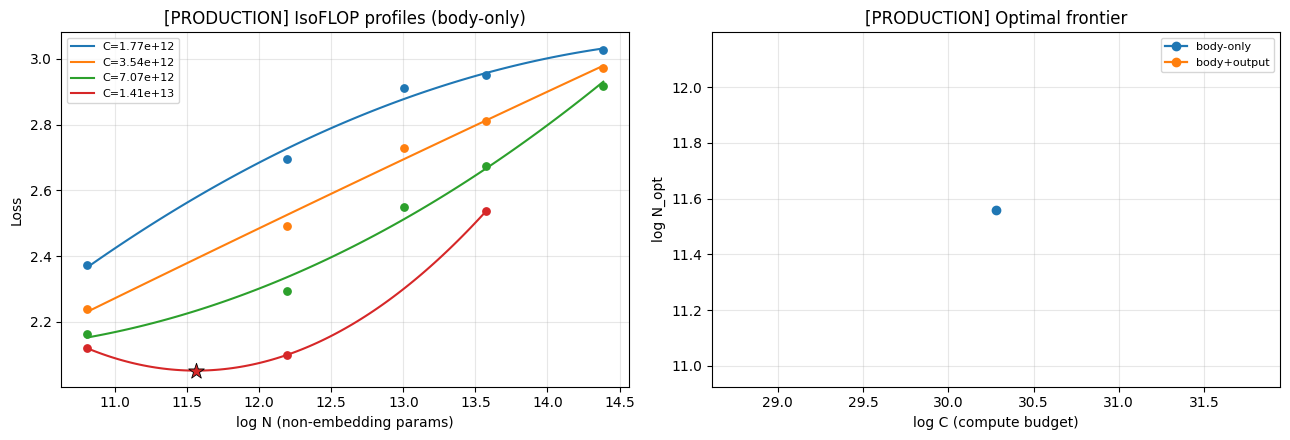

In [26]:
_PLOT_LABEL = "SMOKE" if SMOKE_TEST else "PRODUCTION"  # 009 第 2 ラウンド修正: SMOKE_TEST に連動させる
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

_body_result_demo = reconstruct_optimal_frontier(grid_points, COMPUTE_BUDGETS, FLOPS_PER_TOKEN_BODY)
plot_isoflop_profile(
    _body_result_demo.profiles, title=f"[{_PLOT_LABEL}] IsoFLOP profiles (body-only)", ax=axes[0]
)

_bo_result_demo = reconstruct_optimal_frontier(grid_points, COMPUTE_BUDGETS, FLOPS_PER_TOKEN_BODY_OUTPUT)
_frontiers_demo = {
    "body-only": (
        _body_result_demo.frontier_log_c,
        _body_result_demo.frontier_log_n_opt,
        _body_result_demo.power_law_fit.exponent if _body_result_demo.power_law_fit else None,
    ),
    "body+output": (
        _bo_result_demo.frontier_log_c,
        _bo_result_demo.frontier_log_n_opt,
        _bo_result_demo.power_law_fit.exponent if _bo_result_demo.power_law_fit else None,
    ),
}
plot_optimal_frontier(_frontiers_demo, title=f"[{_PLOT_LABEL}] Optimal frontier", ax=axes[1])
plt.tight_layout()
plt.show()


## 8. 結果・考察 / Results and Discussion

**この節は第 1 段階(Claude Code、ローカル実行)の時点では未記入である。** CLAUDE.md の規約により、スモークテストの数値に基づいて本節の本文を書くことはしない(本番実行後に数値がすべて変わるため)。以下は、本番実行(Google Colab、`SMOKE_TEST=False`)後に記述する内容の見出しと箇条書きのみである。

**009 第 2 ラウンド修正についての注記**: 1 回目の本番実行では、`D_MODEL_LEVELS=[96,128,192,256,352]`・`TARGET_TOKENS_PER_PARAM_MID=1.0`の設計のもとで前提条件 P1 が全計算量予算で不成立となり、実験 A・B・C すべてが判定不能(前提不成立)に終わった。2.1・2.2 節の再設計(`D_MODEL_LEVELS=[32,64,96,128,192]`・`TARGET_TOKENS_PER_PARAM_MID=3.0`)による 2 回目の本番実行の結果を、以下に記述する。

### 8.1 学習グリッドと較正

- 較正で採用した学習率・gradient clipping 閾値と、その根拠となった数値(5.9 節)。学習率の適応的探索(5.9 節)がどの理由(発散 / 頭打ち / `MAX_LR_MULTIPLIER`到達)で終了したか。
- 本番グリッド(25 セル)の実行時間の実測値と、5.11 節の見積もりとの比較。
- 前提条件 P0(学習の進行)・前提条件 P3(データ再利用の上限、実測データ再利用比率)の実測結果。
- 学習グリッドの生データ(`009_grid_results.json`)がコミットされていることの確認。

### 8.2 実験 A: IsoFLOP プロファイルによるべき乗則の妥当性

- 前提条件 P1(内点予算の数)・P3 の実測結果。前提不成立であれば、その旨をそのまま報告する。
- 判定基準による支持 / 反証 / 判定不能の結論。
- $a_{\text{本体}}$ の推定値・ブートストラップ標準偏差。Chinchilla の 0.5・Kaplan らの 0.73 との比較は、事前宣言した判定とは節を分け、事後的な参考として述べる。

### 8.3 実験 B: 最終層の計算量の扱いが指数に与える影響

- 判定基準による支持 / 反証 / 判定不能の結論。
- $a_{\text{本体}}$・$a_{\text{本体+出力層}}$・$\Delta a$ の実測値。
- 診断量(Attention の系列長依存項を加えた数え方での $a$)の値。
- Porian et al. (2024) の要因 1 の再現として解釈できるかどうかの考察(事後的な解釈であることを明示する)。

### 8.4 実験 C: 2 つの推定法の内的整合性

- 前提条件 P2(識別可能性、$\alpha \cdot \beta$ の変動係数)・P3 の実測結果。前提不成立であれば、その旨をそのまま報告する。
- `fit_chinchilla_parametric`の数値的頑健性の修正(009 第 2 ラウンド修正、`src/scaling/laws.py`)後、実データで`converged`・`overflow`警告の有無がどう変化したか。
- 判定基準による支持 / 反証の結論。
- $a_{\text{Approach3}}$・$\alpha$・$\beta$ の実測値。

### 8.5 スケーリング則の小規模実験としての限界(総合考察)

- 計算量の範囲が 1.5 桁程度に限られることが、指数推定の不確かさにどう表れたか。
- 3 つの実験を通じて得られた、小スケールでも成立する構造的な主張のまとめ。
